# Détection de Fraude Financière — Travaux Pratiques Complets de Data Mining
## Un Projet End-to-End de Data Science pour la Prise de Décision Métier

---

### Objectif Global
Maîtriser l'**ensemble du pipeline Data Science/Data Mining** sur un cas réel de détection de fraude financière :
- **Exploration (EDA)** : Comprendre les données (distributions, déséquilibres, patterns)
- **Préprocessing** : Nettoyage, gestion des valeurs manquantes, encodage
- **Feature Engineering** : Création et sélection de features pertinentes
- **Gestion du déséquilibre** : SMOTE, class_weight, ajustement du seuil
- **Modélisation** : DecisionTreeClassifier avec tuning d'hyperparamètres
- **Évaluation** : Métriques adaptées (F1, ROC, AUC-PR) et interprétabilité métier

### Algorithme Principal
- **DecisionTreeClassifier** (Decision Tree / Arbre de décision)
  - Modèle interprétable et rapide
  - Hyperparamètres clés: max_depth, min_samples_split, min_samples_leaf, criterion
  - Tuning complet avec GridSearchCV

### Structure du Notebook
1. **Imports & Configuration** : Toutes les librairies et variables globales
2. **Chargement des données** : Inspection rapide des dimensions et types
3. **Analyse Exploratoire (EDA)** : Distribution cible, variables numériques, catégories
4. **Préprocessing** : Gestion des valeurs manquantes, encodage
5. **Feature Engineering** : Création et sélection de features 
6. **Train/Test Split** : Validation croisée stratifiée
7. **Entraînement du modèle** : DecisionTree avec différentes configurations
8. **Tuning d'hyperparamètres** : GridSearchCV pour trouver la meilleure config
9. **Évaluation & Interprétation** : Métriques, courbes ROC, feature importance
10. **Déploiement** : Sauvegarde du modèle *(À venir)*

---

**🔍 Note de lecture** : Chaque section python a des commentaires détaillés. Chaque graphique est expliqué dans la section markdown qui le précède.

## Installation des dépendances

Nous allons installer toutes les librairies nécessaires pour ce projet. Exécutez cette cellule pour vous assurer que l'environnement est prêt.

In [225]:
pip install pandas numpy missingno matplotlib seaborn scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Imports & Configuration

On commence par importer toutes les librairies nécessaires et définir des constantes pour la reproductibilité. La graine aléatoire (`RANDOM_STATE`) garantit que tous les résultats sont reproductibles d'une exécution à l'autre.

In [226]:
#IMPORT DES LIBRAIRIES

# Objectif: Importer toutes les librairies nécessaires et configurer 
# l'environnement pour la cohérence des résultats et de la visualisation

# IMPORTS - Manipulation des données
import pandas as pd              # DataFrames pour manipuler les données tabulaires
import numpy as np               # Opérations numériques optimisées
import missingno                 # Visualisation des valeurs manquantes
import warnings
warnings.filterwarnings('ignore')  # Supprime les avertissements non critiques

# IMPORTS - Visualisation
import matplotlib.pyplot as plt   # Création de graphiques
import seaborn as sns             # Esthétique améliorée pour matplotlib

# Configuration globale du style visuel (s'applique à tous les graphiques)
plt.rcParams['figure.dpi'] = 110                  # Résolution: 110 points par pouce
plt.rcParams['font.family'] = 'DejaVu Sans'       # Police uniforme
sns.set_theme(style='whitegrid', palette='Set2')  # Thème avec grille blanche

# Palette de couleurs: green=transactions légitimes, red=fraudes
PALETTE = ['#2ecc71', '#e74c3c']  

# IMPORTS - Preprocessing & Feature Engineering
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV,
    cross_val_score, learning_curve
)

from sklearn.preprocessing import (
    LabelEncoder,                 # Encode variables catégorielles en nombres
    StandardScaler,               # Normalise: moyenne=0, écart-type=1
    MinMaxScaler                  # Normalise: min=0, max=1
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

# IMPORTS - Modèles ML
from sklearn.tree import (
    DecisionTreeClassifier,       # Arbre de décision (modèle principal du projet)
    export_text,                  # Exporte l'arbre en texte lisible
    plot_tree                     # Visualise l'arbre de décision
)

# IMPORTS - Métriques et évaluations
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score,
    ConfusionMatrixDisplay
)

# SMOTE (Synthetic Minority Over-sampling Technique) génère des données synthétiques
# pour équilibrer les classes. C'est une alternative à utiliser en TRAIN SEULEMENT
try:
  from imblearn.over_sampling import SMOTE
  from imblearn.pipeline import Pipeline as ImbPipeline
  SMOTE_AVAILABLE = True
  print('imbalanced-learn disponible - SMOTE activé')
except ImportError:
  SMOTE_AVAILABLE = False
  print('imbalanced-learn non installé - on utilisera class_weight')

# Constantes globales pour la reproductibilité
RANDOM_STATE = 42              # Graine aléatoire: garantit des résultats identiques à chaque exécution
TEST_SIZE = 0.2                # Proportion du test set: 20% test, 80% train

imbalanced-learn disponible - SMOTE activé


## 2. Chargement & Premier Aperçu des Données

Dans cette section nous allons charger le dataset dans la structure de données DataFrame. On commencera par une inspection rapide : types de colonnes, valeurs manquantes, premières lignes.

In [227]:
DATA_PATH = '/home/angelo-btma/Téléchargements/Fraud Detection Dataset.csv'
df = pd.read_csv(DATA_PATH)

# Affiche les informations de base
print()
print('='*48)
print(f'DATASET CHARGÉ AVEC: {df.shape[0]} lignes et {df.shape[1]} colonnes')
print('='*48)
df.head(10)


DATASET CHARGÉ AVEC: 51000 lignes et 12 colonnes


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
5,T6,2095,2372.04,ATM Withdrawal,15.0,Desktop,Boston,3,96,14,Credit Card,0
6,T7,4772,544.81,Bill Payment,2.0,Tablet,Boston,3,6,9,UPI,1
7,T8,4092,635.75,ATM Withdrawal,13.0,Tablet,Boston,2,13,10,Debit Card,0
8,T9,2638,2318.87,Bank Transfer,NaN,Mobile,San Francisco,4,110,12,Debit Card,0
9,T10,3169,3656.17,Bill Payment,3.0,Mobile,Chicago,4,66,3,Net Banking,0


In [228]:
TARGET = 'Fraudulent'
print('TYPES DE DONNÉES & VALEURS NON-NULLES:')
print('='*70)
df.info()

TYPES DE DONNÉES & VALEURS NON-NULLES:
<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  str    
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  str    
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  str    
 6   Location                          48453 non-null  str    
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  str    
 11  Fraudulent                        51000

In [229]:
# Apercu des statistiques descriptives globales
print("STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES")
print("="*70)
print()
display(df.describe().T)  # .T transpose le DataFrame pour mieux lire

STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES



,count,mean,std,min,25%,50%,75%,max
User_ID,51000.0,3005.110176,1153.121107,1000.00,2007.0000,2996.0,4006.00,4999.0
Transaction_Amount,48480.0,2996.249784,5043.932555,5.03,1270.5525,2524.1,3787.24,49997.8
Time_of_Transaction,48448.0,11.488400,6.922954,0.00,5.0000,12.0,17.00,23.0
Previous_Fraudulent_Transactions,51000.0,1.995725,1.415150,0.00,1.0000,2.0,3.00,4.0
Account_Age,51000.0,60.033902,34.384131,1.00,30.0000,60.0,90.00,119.0
Number_of_Transactions_Last_24H,51000.0,7.495588,4.020080,1.00,4.0000,7.0,11.00,14.0
Fraudulent,51000.0,0.049216,0.216320,0.00,0.0000,0.0,0.00,1.0


In [230]:
# Objectif: Identifier toutes les colonnes de type "object" (texte/catégories),
# compter le nombre de valeurs uniques, et afficher un échantillon

# Sélectionne toutes les colonnes de type objet (chaînes de caractères)
cat_cols = df.select_dtypes(include='object').columns.tolist()

print('='*70)
print('VARIABLES CATÉGORIELLES: Types et valeurs uniques')
print('='*70)
print()

for col in cat_cols:
    uniques = df[col].unique()  # Récupère les valeurs distinctes
    # Affiche: Nom de colonne → Nb unique de valeurs → Les 8 Premiers exemples 
    print(f'{col:35s} → {len(uniques):3d} valeurs uniques | Exemples: {list(uniques[:8])}')


VARIABLES CATÉGORIELLES: Types et valeurs uniques

Transaction_ID                      → 50000 valeurs uniques | Exemples: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8']
Transaction_Type                    →   5 valeurs uniques | Exemples: ['ATM Withdrawal', 'Bill Payment', 'POS Payment', 'Bank Transfer', 'Online Purchase']
Device_Used                         →   5 valeurs uniques | Exemples: ['Tablet', 'Mobile', 'Desktop', nan, 'Unknown Device']
Location                            →   9 valeurs uniques | Exemples: ['San Francisco', 'New York', nan, 'Chicago', 'Boston', 'Houston', 'Miami', 'Los Angeles']
Payment_Method                      →   6 valeurs uniques | Exemples: ['Debit Card', 'Credit Card', nan, 'UPI', 'Net Banking', 'Invalid Method']


VALEURS MANQUANTES



,Valeurs Manquantes,% manquant
Time_of_Transaction,2552,5.00
Location,2547,4.99
Transaction_Amount,2520,4.94
Device_Used,2473,4.85
Payment_Method,2469,4.84


Résultat: 5 colonne(s) affectée(s) sur 12


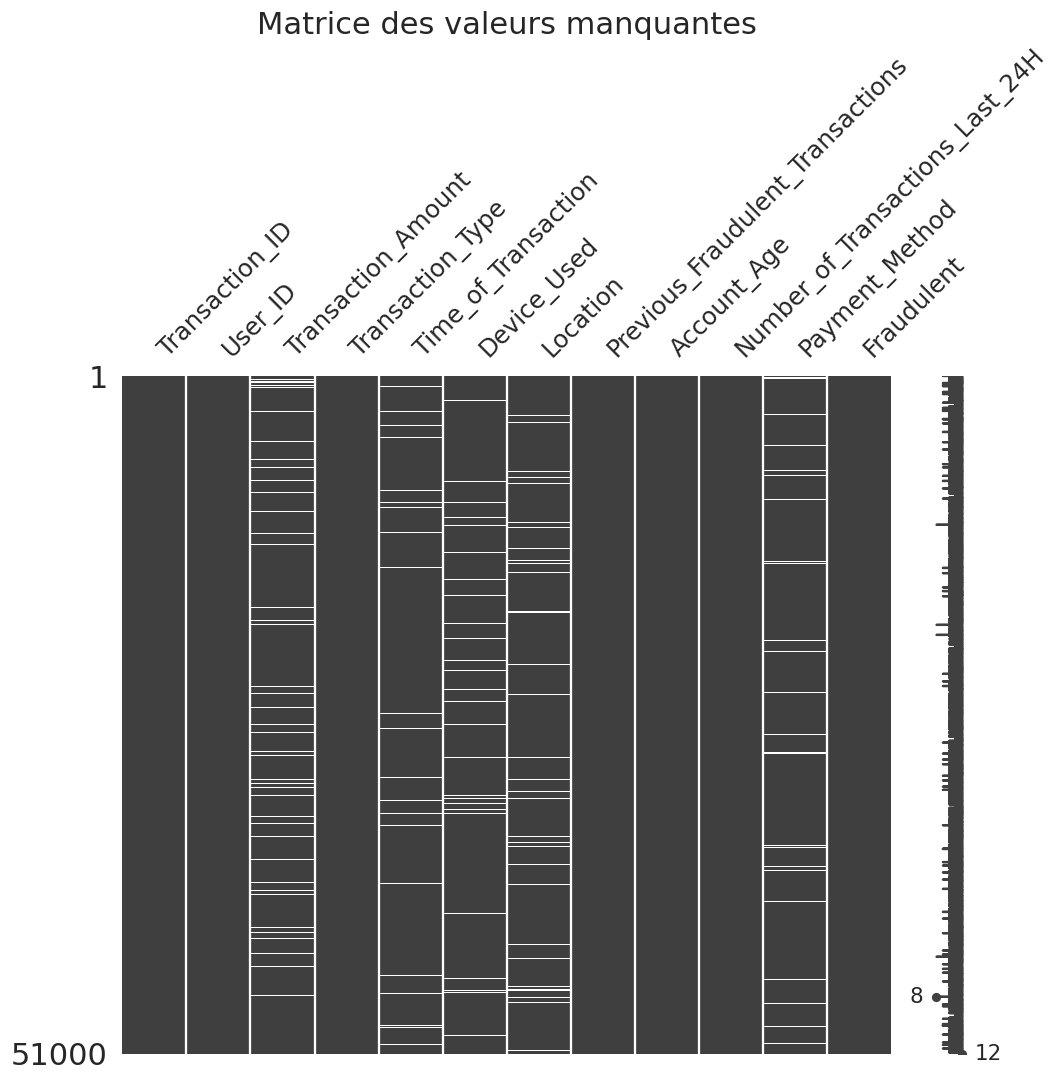

In [231]:
# Analyse complète des valeurs manquantes (MISSING DATA ANALYSIS)

# Objectif: Identifier quelles colonnes ont des valeurs manquantes et 
# quantifier l'impact en nombre et en pourcentage

# Calcul du nombre et pourcentage de valeurs manquantes par colonne
missing = df.isnull().sum()                     # Nombre de NaN par colonne
missing_pct = ((missing/len(df))*100).round(2)  # Pourcentage par colonne

# Création d'un DataFrame récapitulatif pour meilleure lisibilité
missing_df = pd.DataFrame({
    'Valeurs Manquantes': missing,
    '% manquant': missing_pct
}).query('`Valeurs Manquantes`>0').sort_values('% manquant', ascending=False)  # Filtre et trie

print('VALEURS MANQUANTES')
print()
display(missing_df)
print(f'Résultat: {len(missing_df)} colonne(s) affectée(s) sur {df.shape[1]}')

#Matrice des valeurs manquantes
missingno.matrix(df, filter = 'top', figsize = (10, 8))
plt.title('Matrice des valeurs manquantes', fontsize=20)
plt.show()

Nous reviendrons dans une section spéciale dédiée au préprocessing voir comment on va gerer ces valeurs manquantes

## 3. Analyse Exploratoire des Données (EDA)

L'EDA est l'étape fondamentale qui va nous permettre de **comprendre les données** avant de les modéliser. On va analyser :
- La distribution de la variable cible (Fraude vs Légitime)
- Les distributions des variables numériques par classe
- Les relations entre features et la cible
- Les patterns de fraude par catégorie

### 3.1. Distribution de la Variable Cible

**Qu'allons-nous voir ?**
- Un histogramme montrant le nombre brut de transactions légitimes vs frauduleuses
- Un camembert affichant les proportions (%)
- Une analyse du déséquilibre: combien de fraudes proportionnellement?

**Pourquoi c'est important ?**
Si nous trouvons un déséquilibre (par ex. 98% de transactions légitimes, 2% frauduleuses), nous aurons besoin de:
- Métriques spéciales (F1-Score, AUC-PR) au lieu de l'accuracy
- Techniques de rééquilibrage (SMOTE, class_weight)
- Ajustement du seuil de classification

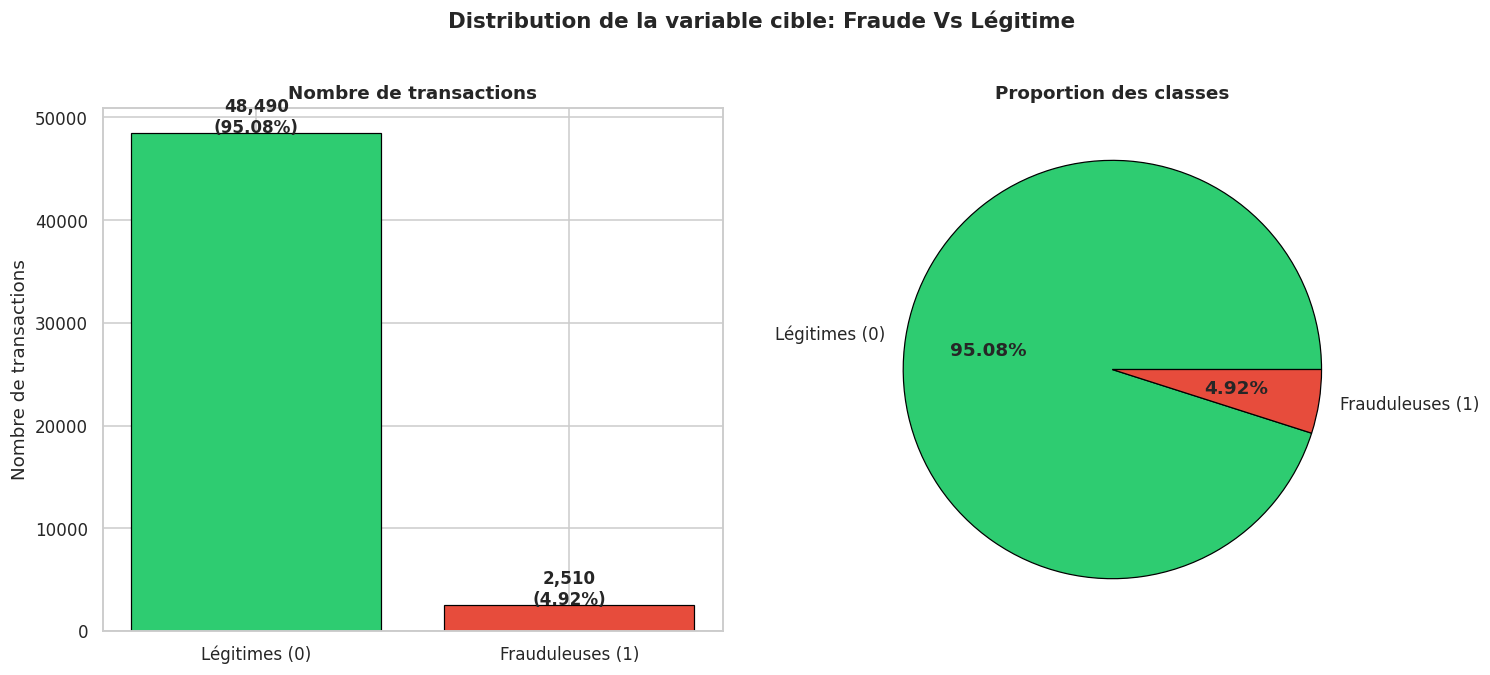

DESEQUILIBRE DÉTECTÉ: ratio 4.92 (Légitime Vs Frauduleuse)
-> Cela implique d'utiliser des métriques adaptées : F1, AUC-PR, Recall
-> Stratégies : SMOTE, class_weight='balanced', ajustement du seuil


In [232]:
# GRAPHIQUE 1: Distribution de la variable cible - Fraude vs Légitime

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution de la variable cible: Fraude Vs Légitime', fontsize = 14, fontweight = 'bold', y=1.02)

# Compter les occurrences de chaque classe
counts = df[TARGET].value_counts()
labels = ['Légitimes (0)', 'Frauduleuses (1)']
colors = ['#2ecc71', '#e74c3c']  # Vert pour légitime, rouge pour fraude

#Barplot
axes[0].bar(labels, counts.values, color = colors, edgecolor = 'black', linewidth = 0.8)
for i, v in enumerate(counts.values):
  axes[0].text(i, v+50, f'{v:,}\n({v/len(df)*100:.2f}%)', ha = 'center', fontweight = 'bold', fontsize = 11)
  axes[0].set_title('Nombre de transactions', fontweight= 'bold')
  axes[0].set_ylabel('Nombre de transactions')


#CAMEMBERT (Pie chart)
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels = labels, colors =colors,
    autopct = '%1.2f%%', wedgeprops = {'edgecolor':'black', 'linewidth':0.8}
)
for at in autotexts:
  at.set_fontsize(12)
  at.set_fontweight('bold')
axes[1].set_title('Proportion des classes', fontweight = 'bold')

plt.tight_layout()
plt.savefig('fig_target_distribution.png', bbox_inches = 'tight', dpi = 120)
plt.show()

pct_ratio = (counts[1]/(counts[0]+counts[1]))*100
print(f'DESEQUILIBRE DÉTECTÉ: ratio {pct_ratio:.2f} (Légitime Vs Frauduleuse)')
print(f"-> Cela implique d'utiliser des métriques adaptées : F1, AUC-PR, Recall")
print(f"-> Stratégies : SMOTE, class_weight='balanced', ajustement du seuil")

**Interprétation du déséquilibre de classes :**

En data science, il n'existe pas de seuil mathématique rigide, mais on considère généralement qu'un recours à ces métriques spéciales est indispensable dès que le déséquilibre atteint 1:10 (10% de minorité).

Voici comment situer l'urgence :
- **Déséquilibre léger (60/40 à 70/30)** : L'Accuracy reste acceptable, mais commence à être "flatteuse"
- **Déséquilibre modéré (80/20 à 90/10)** : Zone critique. Si on prédit "Légitime" tout le temps, on a 90% d'accuracy mais on rate 100% des fraudes!
- **Déséquilibre sévère (99/1 ou plus)** : Typique de détection de fraude. L'accuracy est inutile (99% est un échec total). Le **F1-Score** et l'**AUC-PR** sont les métrics qui viendront trancher .

---

### 3.2. Distribution des Variables Numériques par Classe

**Qu'allons-nous voir ?**
- 5 histogrammes (un par variable numérique)
- Pour chaque variable: superposition des distributions Légitimes (vert) vs Frauduleuses (rouge)

**Pourquoi c'est important ?**
À la recherche de **patterns** qui distinguent les fraudes des transactions normales. Par exemple:
- Les fraudes ont-elles des montants anormalement élevés ou bas?
- Certains horaires sont-ils plus risqués?
- Les fraudeurs réutilisent-ils les âmes comptes?

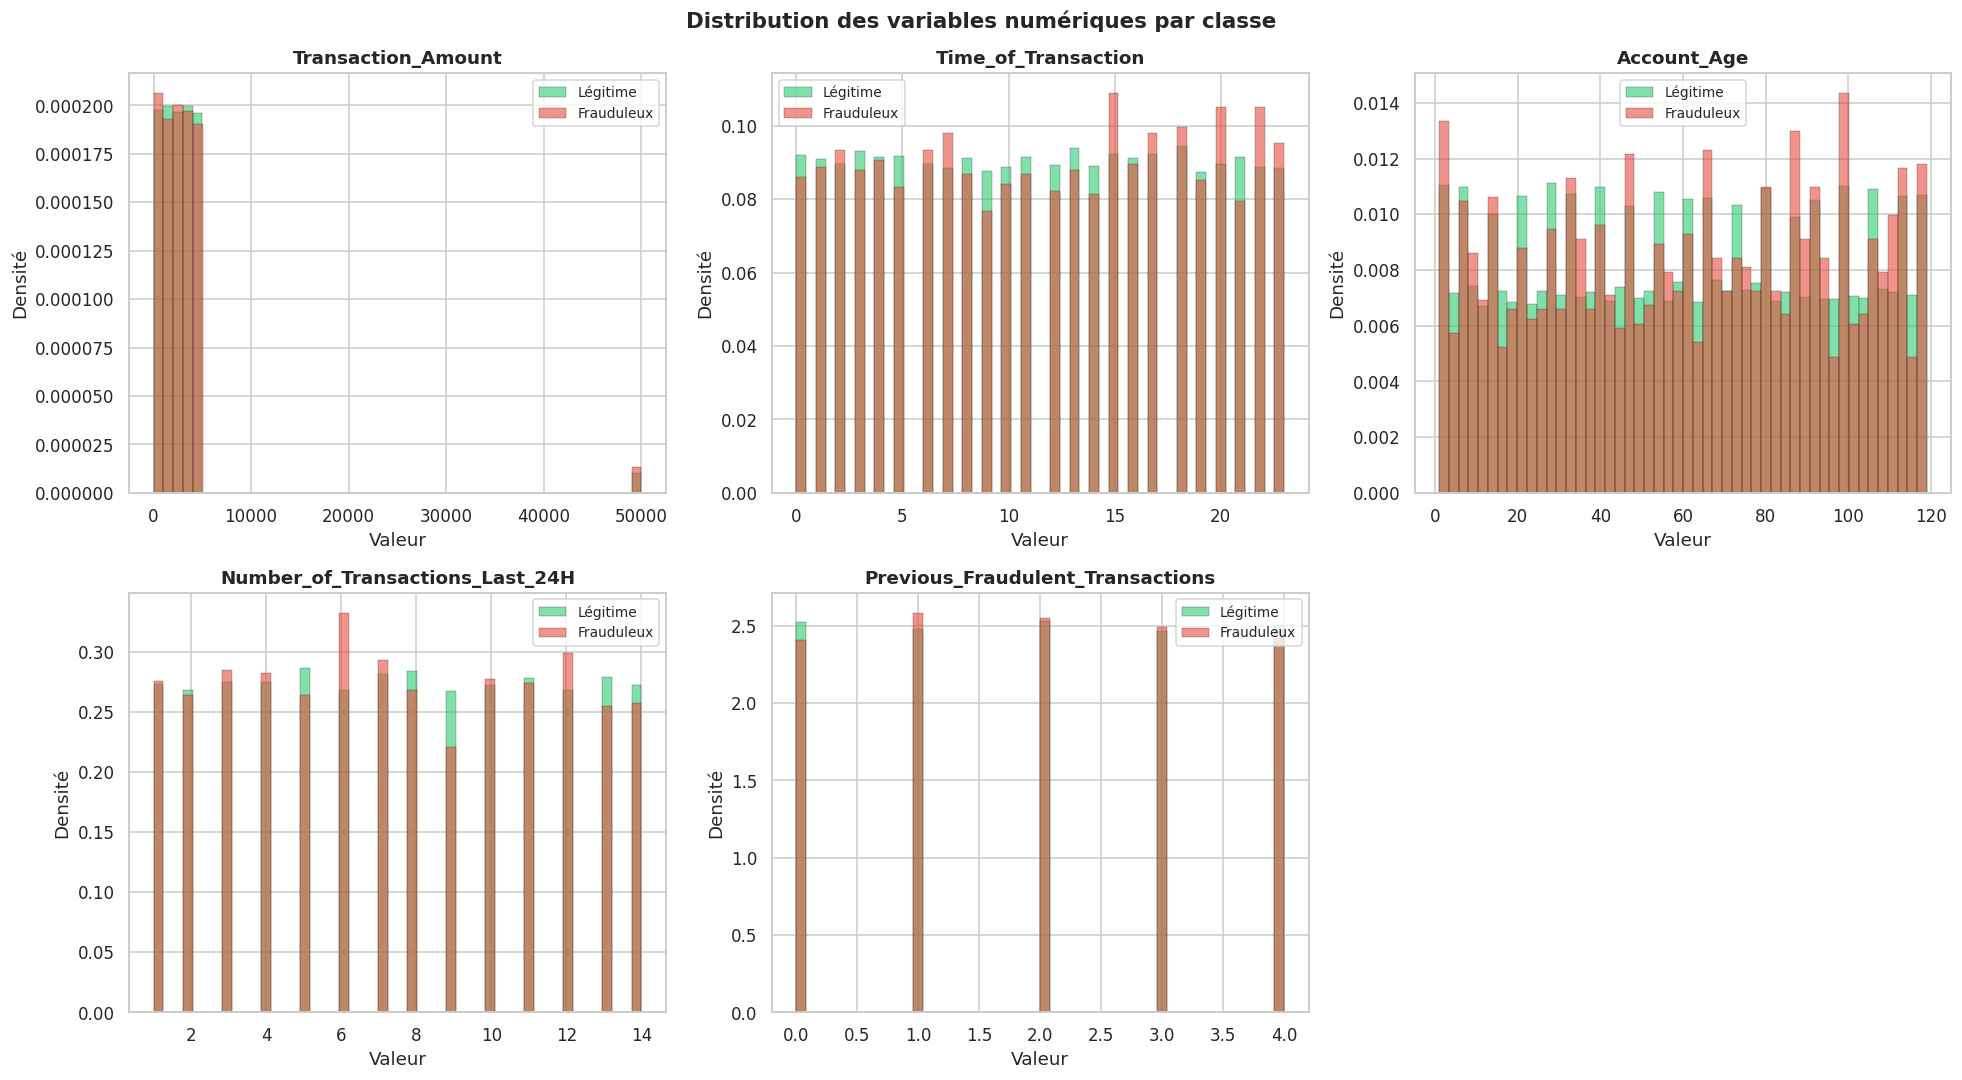

In [233]:
# Distribution des variables numériques par classe
# Objectif: Comparer les distributions des features numériques entre

# Subdivision en sous ensemble légitime et frauduleux - pour détecter des patterns distincts

# Liste des variables numériques à analyser
num_cols = ['Transaction_Amount', 'Time_of_Transaction',
            'Account_Age', 'Number_of_Transactions_Last_24H',
            'Previous_Fraudulent_Transactions']
fig, axes = plt.subplots(2, 3, figsize = (18, 10))
axes = axes.flatten()
fig.suptitle("Distribution des variables numériques par classe", fontsize = 14, fontweight = 'bold')

for i, col in enumerate(num_cols):
    # Pour chaque classe (0=Légitime, 1=Frauduleuse)
    for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], 
                                   ['Légitime', 'Frauduleux']):
        # Sélectionne les données de cette classe pour cette colonne (supprime les NaN)
        subset = df[df[TARGET] == label][col].dropna()
        
        # Crée un histogramme pour cette sous-population
        axes[i].hist(
            subset,
            bins=50,                    
            alpha=0.6,                  
            color=color,               
            label=name,                
            density=True,               
            edgecolor='black',          
            linewidth=0.25
        )
    
    # Formatage de chaque sous-graphique
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Densité')
    axes[i].legend(fontsize = 9)
axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('fig_distributions_vars_numeriques.png', bbox_inches = 'tight', dpi =120)
plt.show()

### 3.3. Taux de Fraude par Variable Catégorielles

**Qu'allons-nous voir ?**
- 4 graphiques en barres (un par variable catégoriques: Type de transaction, Appareil, Localisation, Méthode de paiement)
- Pour chaque catégorie: le pourcentage de fraudes
- Les catégories sont triées de la plus risquée à la plus sûre

**Pourquoi c'est important ?**
Certaines catégories sont peut-être des **facteurs de risque**. Par exemple:
- Certains types de transactions sont-elles plus souvent frauduleuses?
- Les utilisateurs mobiles sont-ils plus à risque que les utilisateurs desktop?
- Certains pays/régions ont-ils un taux de fraude plus élevé?

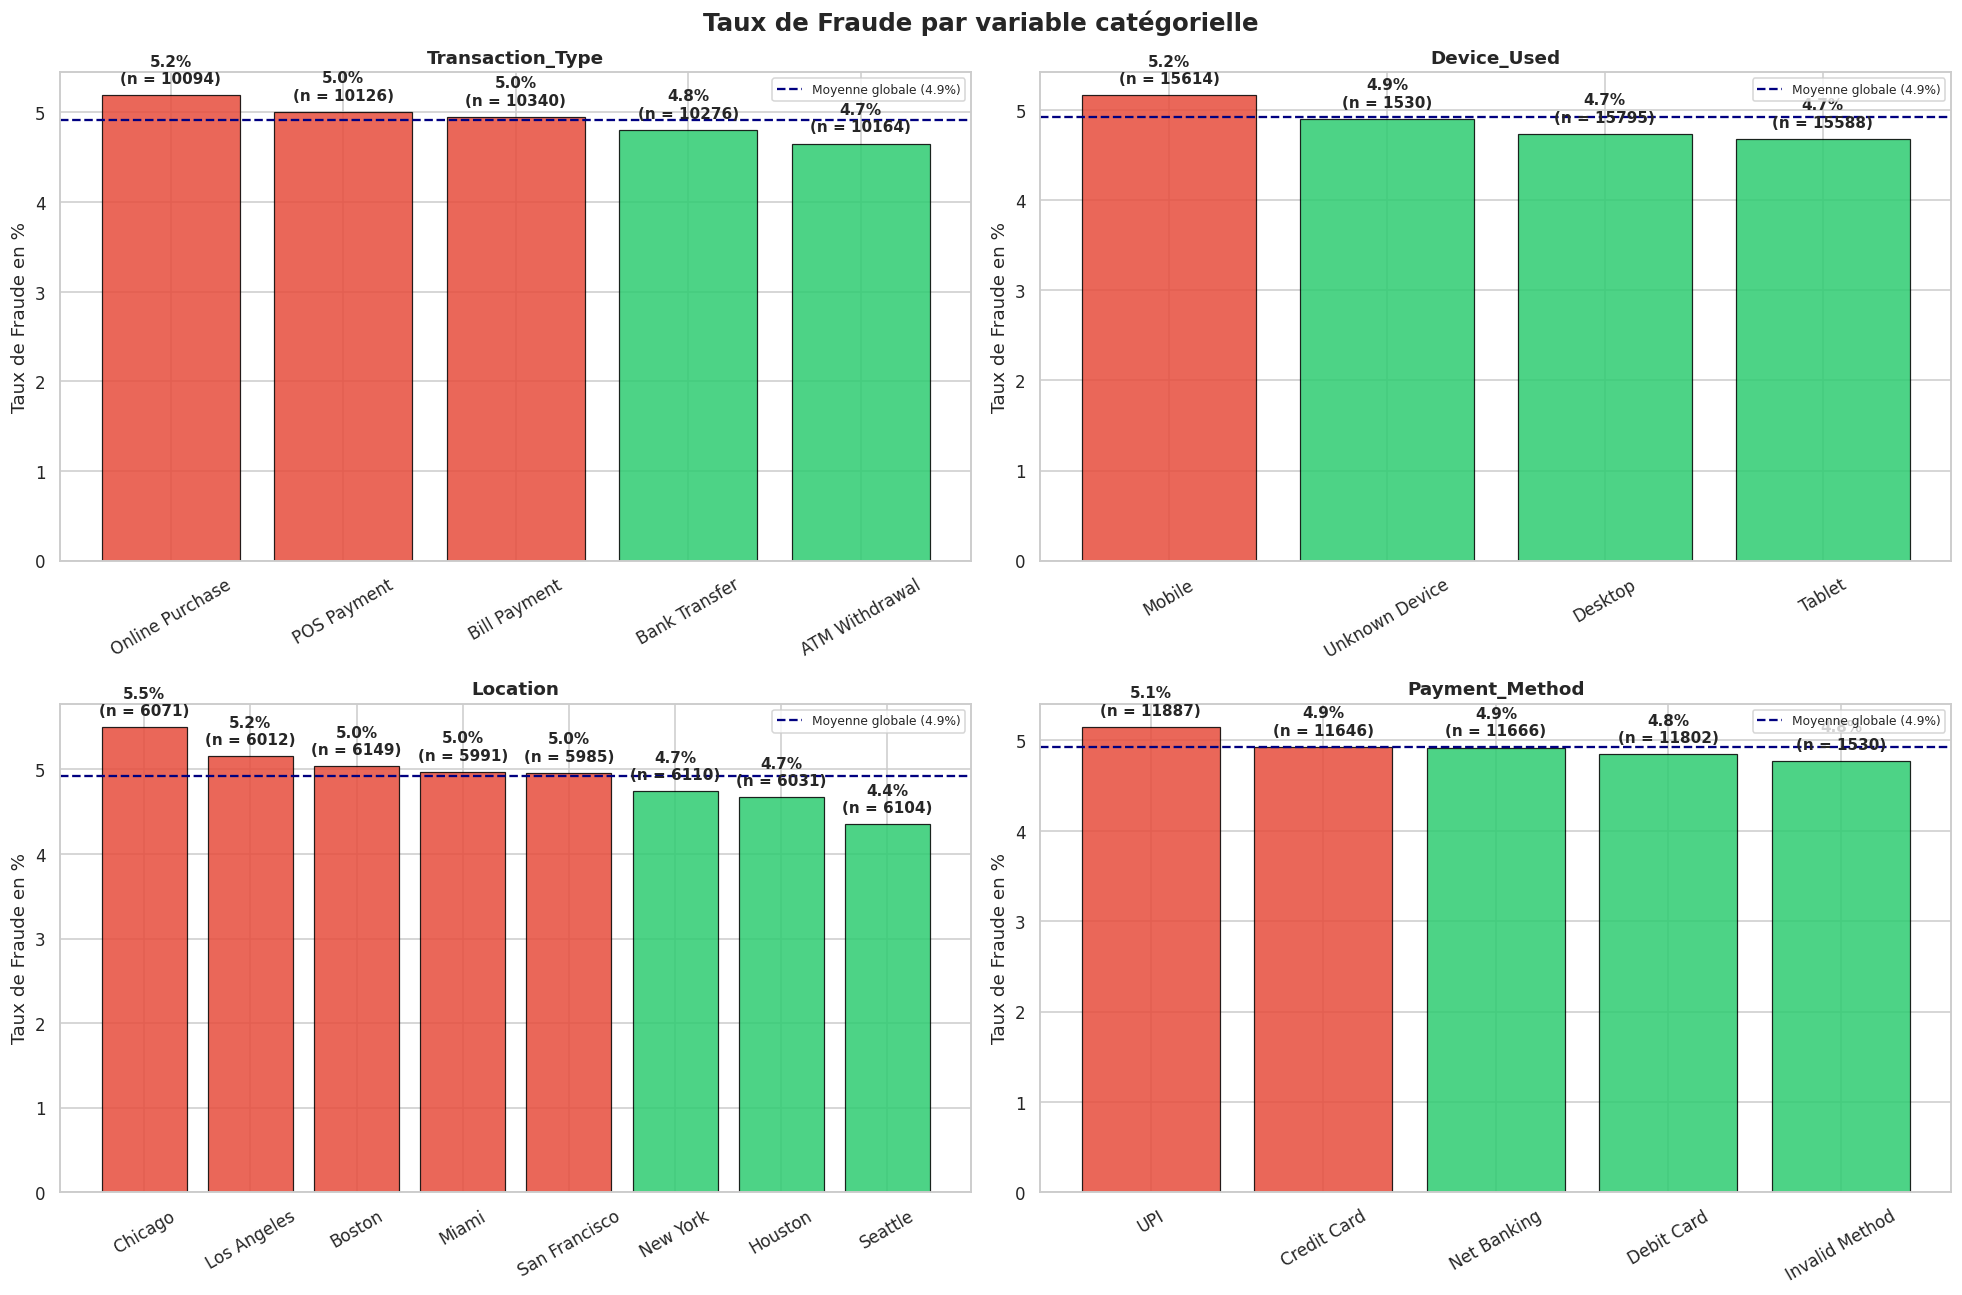

In [234]:
# Taux de Fraude par Variable Catégorielles

# Objectif: Identifier les variables catégorielles qui sont associées à un 
# risque de fraude plus élevé (facteurs de risque potentiels)

# Liste des variables catégorielles à analyser
cat_analysis = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

# Création d'une grille 2x2 pour 4 graphiques
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Taux de Fraude par variable catégorielle', fontsize=16, fontweight='bold', y=0.98)

# Boucle: pour chaque variable catégorielles, calculer et visualiser le taux
for ax, col in zip(axes.flatten(), cat_analysis):
    # Calcule le taux de fraude par catégories
    # .agg(['mean', 'count']) → mean=taux fraude (car TARGET est 0/1), count=nb transactions
    fraud_rate = df.groupby(col)[TARGET].agg(['mean', 'count']).reset_index()
    fraud_rate.columns = [col, 'fraud_rate', 'count']
    fraud_rate = fraud_rate.sort_values('fraud_rate', ascending=False)  # Tri: croissant
    
    # Crée le graphique en barres
    bars = ax.bar(
        fraud_rate[col],                          # X: catégories
        fraud_rate['fraud_rate'] * 100,          # Y: taux fraude en %
        color=['#e74c3c' if r > df[TARGET].mean() else '#2ecc71' for r in fraud_rate['fraud_rate']],
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )
    
    # Annotations: taux et nombre
    for bar, (_, row) in zip(bars, fraud_rate.iterrows()):
        ax.text(
            bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, 
            f'{row['fraud_rate']*100:.1f}%\n(n = {int(row['count'])})',
            ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold'
        )
    #Tracé d'une ligne verticale au niveau de la target moyenne 
    ax.axhline(
            df[TARGET].mean() * 100, color='navy', linestyle='--',
            linewidth=1.5, label=f'Moyenne globale ({df[TARGET].mean() * 100:.1f}%)'
        )

    ax.set_title(col, fontweight = 'bold')
    ax.set_ylabel('Taux de Fraude en %')
    #Le but de cette ligne est d'améliorer la lisibilité du graphique en tournant 
    #les étiquettes de l'axe des abscisses pour éviter qu'elles ne se chevauchent. 
    ax.tick_params(axis = 'x', rotation = 30)
    ax.legend(fontsize = 8)

plt.tight_layout()
plt.savefig('Fraude_par_catégorie.png', bbox_inches = 'tight', dpi = 120)
plt.show()


Principales Observations

- Type de Transaction : Les achats en ligne (5.2%) constituent le vecteur de fraude le plus critique, suivis des paiements par terminal (POS) et du règlement de factures. À l'inverse, les retraits aux distributeurs (ATM) s'avèrent être les transactions les plus sûres (4.7%).

- Appareil Utilisé : L'écosystème Mobile (5.2%) est nettement surreprésenté dans les cas de fraude par rapport à la moyenne globale. Les ordinateurs de bureau (Desktop) et les tablettes sont, quant à eux, des canaux moins risqués.

- Localisation : Le risque géographique est très hétérogène. Les villes de Chicago (5.5%) et Los Angeles (5.2%) se démarquent comme des zones d'alerte majeures. En revanche, des villes comme Seattle (4.4%) et Houston (4.7%) affichent des taux d'activité frauduleuse bien moindres.

- Méthode de Paiement : Les paiements via UPI (5.1%) et les Cartes de Crédit sont les méthodes privilégiées par les fraudeurs. Le Net Banking et les Cartes de Débit offrent une meilleure sécurité relative.

### 3.4. Etudes des variables numeriques par rapport à la variable cible

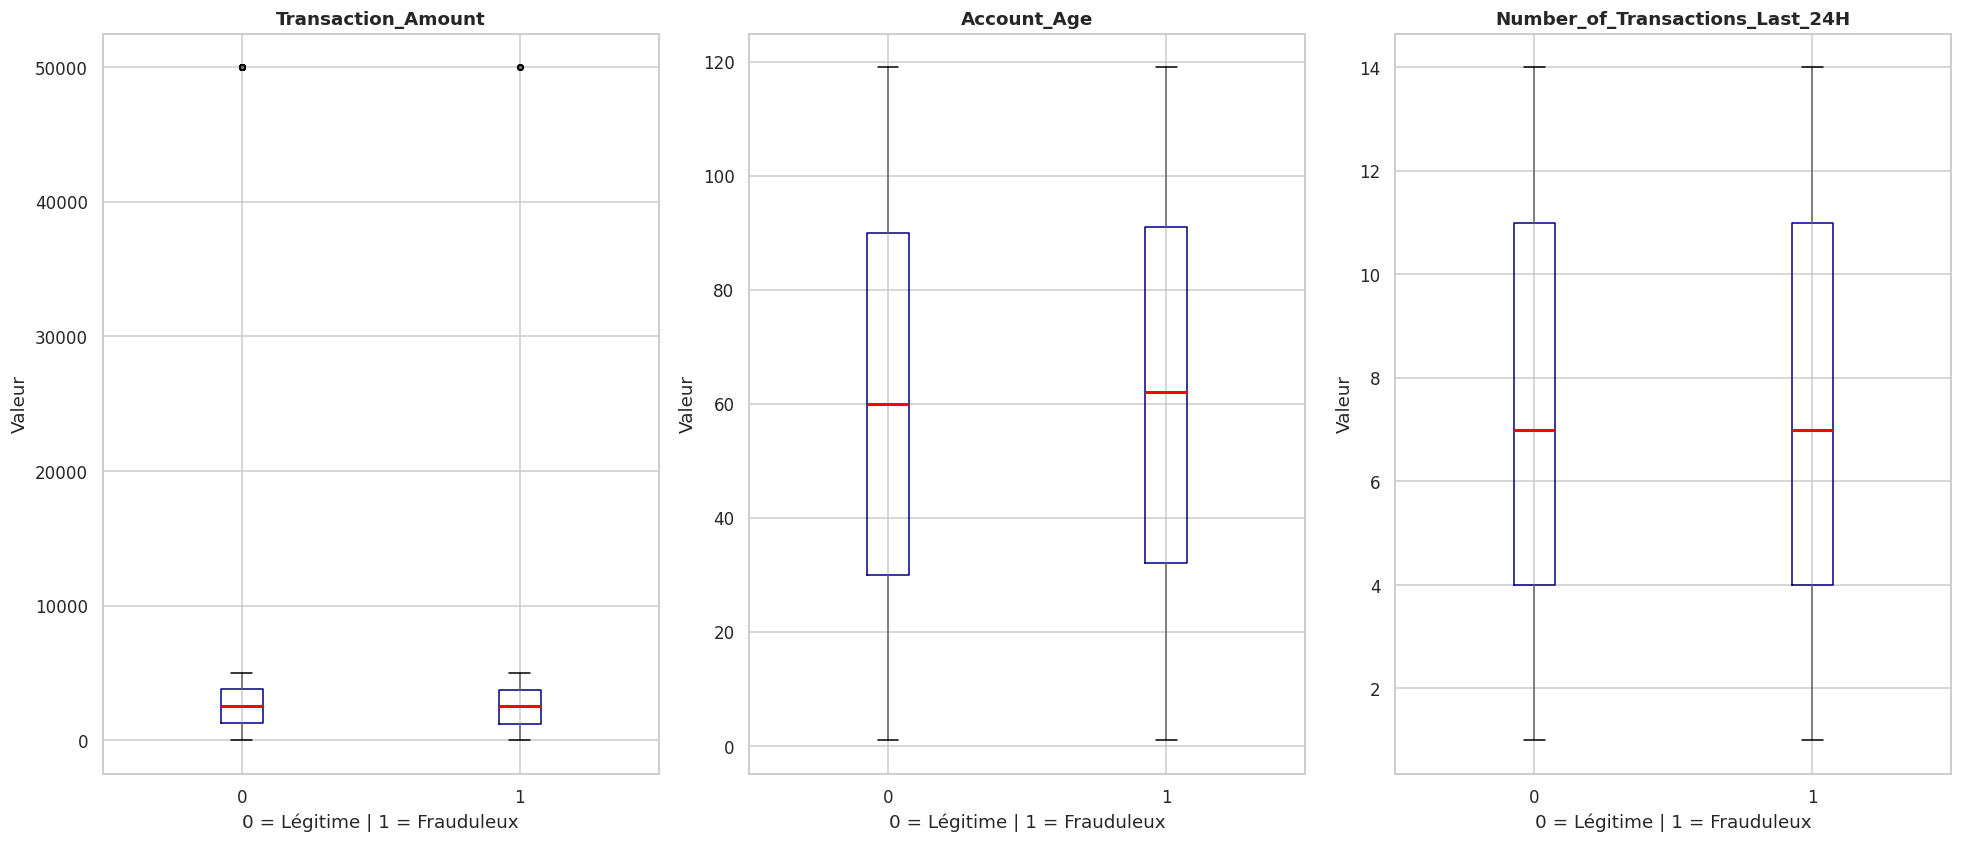

In [235]:
# BOXPLOTS - VARIABLES NUMÉRIQUES VS LA TARGET
fig, axes = plt.subplots(1, 3, figsize = (18, 8))

fig.suptitle('Boxplots: Variables Clés Vs Fraude', fontsize = 13, fontweight = 'bold')

boxplot_cols = ['Transaction_Amount', 'Account_Age', 'Number_of_Transactions_Last_24H']
for ax, col in zip(axes, boxplot_cols):
    df.boxplot(
        column = col, by = TARGET, ax = ax, boxprops = dict(color = 'navy'),
        medianprops = dict(color = 'red', linewidth = 2),
        flierprops = dict(marker = 'o', markerfacecolor = 'gray', markersize = 3)
    )
    ax.set_title(col, fontweight = 'bold')
    ax.set_xlabel('0 = Légitime | 1 = Frauduleux')
    ax.set_ylabel('Valeur')

plt.suptitle('')
plt.tight_layout()
plt.savefig('fig_boxplots.png', bbox_inches ='tight', dpi = 120)
plt.show()

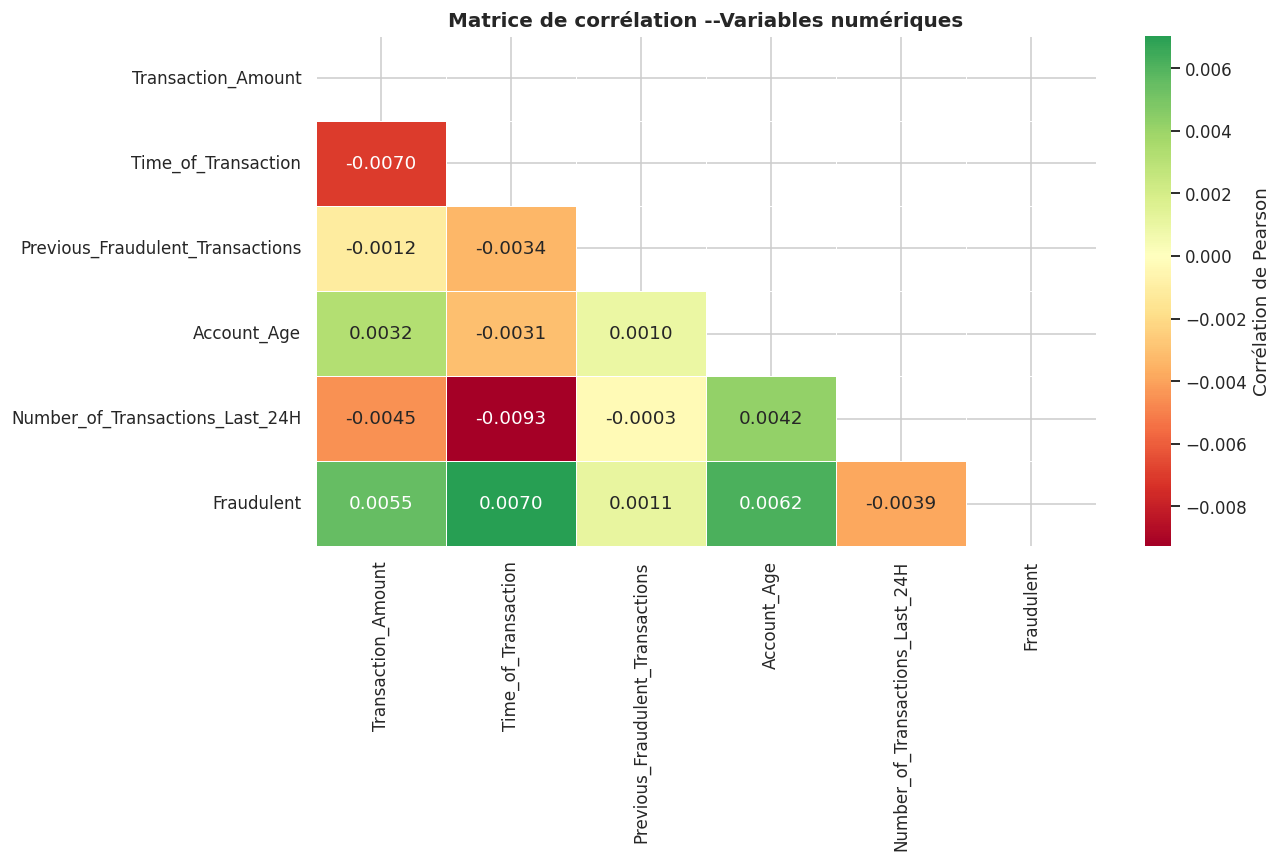


CORRÉLATIONS AVEC LA VARIABLE CIBLE:
Fraudulent                                    +1.0000##############################
Time_of_Transaction                           +0.0070
Account_Age                                   +0.0062
Transaction_Amount                            +0.0055
Number_of_Transactions_Last_24H               -0.0039
Previous_Fraudulent_Transactions              +0.0011


In [236]:
# MATRICE DE CORRÉLATION 

corr_df = df.select_dtypes(include=[np.number]).drop(columns = ['User_ID'])

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_df.corr(), dtype= bool))
sns.heatmap(
    corr_df.corr(), mask = mask, annot= True, fmt='.4f', 
    cmap = 'RdYlGn', center = 0,linewidths= 0.6, 
    cbar_kws = {'label':'Corrélation de Pearson'}
)
plt.title('Matrice de corrélation --Variables numériques', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('Carte des corrélations', bbox_inches = 'tight', dpi = 120)
plt.show()

# Corrélation avec la Target
print()
print('CORRÉLATIONS AVEC LA VARIABLE CIBLE:')
print('='*40)
corrs = corr_df.corr()[TARGET].sort_values(key = abs, ascending= False)
for feature, valeur in corrs.items():
    bar = '#'*int(abs(valeur)*30)
    sign = '+' if valeur>0 else '-'
    print(f'{feature:45s} {sign}{abs(valeur):.4f}{bar}')



### 3.5. Analyse Temporelle dans le but de detecter d'éventuels patterns

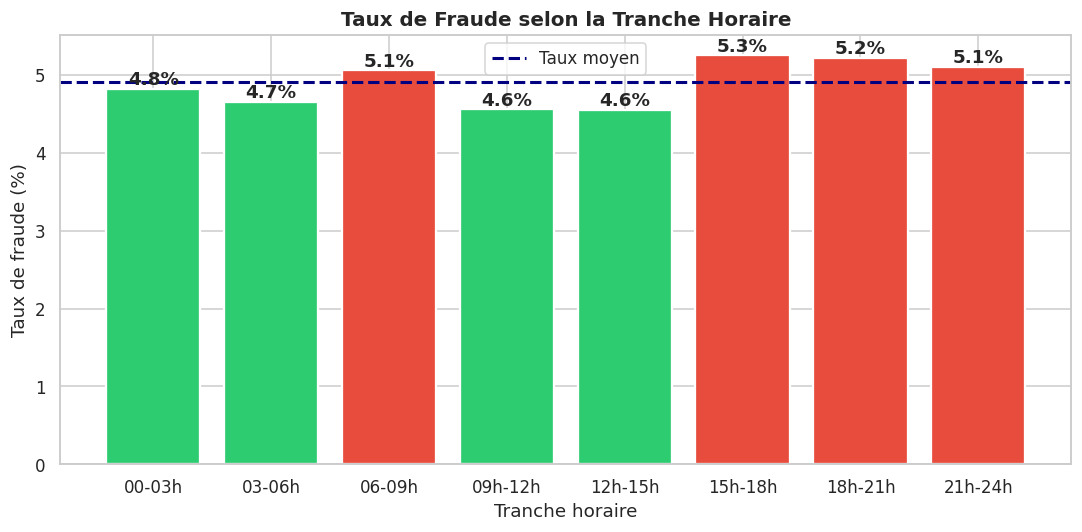

In [237]:
# ANALYSE TEMPORELLE: Fraude selon l'heure
df_temp = df.copy()
df_temp['Hour_bin'] = pd.cut(df_temp['Time_of_Transaction'], bins=8, labels=['00-03h','03-06h','06-09h','09h-12h','12h-15h','15h-18h','18h-21h','21h-24h'])

fraud_by_hour = df_temp.groupby('Hour_bin', observed=True)[TARGET].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(
    fraud_by_hour.index, fraud_by_hour.values, 
    color=[PALETTE[1] if v > fraud_by_hour.mean() else PALETTE[0] for v in fraud_by_hour.values],
    edgecolor='white', linewidth=1.5
)
plt.axhline(fraud_by_hour.mean(), color='navy', linestyle='--', 
            linewidth=2, label='Taux moyen')
for bar, val in zip(bars, fraud_by_hour.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.title("Taux de Fraude selon la Tranche Horaire", fontsize=13, fontweight='bold')
plt.xlabel("Tranche horaire")
plt.ylabel("Taux de fraude (%)")
plt.legend()
plt.tight_layout()
plt.savefig("Fraude partranche d'heures.png", bbox_inches='tight', dpi=120)
plt.show()

Taux de Fraude par Tranche Horaire

- Insight Data : La fraude présente une forte saisonnalité dans l'après midi meme jusqu'au soir. Il y a souvent des pics anormaux (pendant les heures creuses le soir, par exemple entre 18h et minuit), où le volume de transactions normales est très faible.
t
- Hypothèse Business :   
 1.  Automatisation : Les pics nocturnes suggèrent l'utilisation de scripts automatisés ou tout autre moyen du genre qui testent des cartes ou exécutent des virements en masse quand la surveillance humaine (et la vigilance des clients) est au plus bas.  
 2.  Attaques transfrontalières : Les fraudeurs opèrent potentiellement depuis un autre fuseau horaire, ce qui expliquerait un taux de fraude élevé entre 06 heures et 09 9 heures du matin


### 3.5. Synthèse de l'EDA

## 4. Preprocessing — Nettoyage & Transformation

Le preprocessing transforme les données brutes en un format exploitable par les algorithmes ML. C'est souvent **la phase qui a le plus d'impact** sur la qualité du modèle final.

**Étapes :**
1. Suppression des identifiants inutiles
2. Gestion des valeurs manquantes
3. Encodage des variables catégorielles
4. Séparation train/test (avec stratification)
5. Normalisation

In [238]:
# Copie de travail & nettoyage initial 
df_clean = df.copy()

# Supprimer les colonnes identifiants (non informatives pour le modèle)
id_cols = ['Transaction_ID', 'User_ID']
df_clean.drop(columns=id_cols, inplace=True)
print(f'Colonnes identifiants supprimées : {id_cols}')
print(f'Dimensions après suppression : {df_clean.shape}')

Colonnes identifiants supprimées : ['Transaction_ID', 'User_ID']
Dimensions après suppression : (51000, 10)


In [239]:
# Gestion des valeurs aberrantes par la méthode IQR 

# On sélectionne les variables numériques sensibles aux valeurs extrêmes
num_cols_outliers = ['Transaction_Amount', 'Account_Age', 'Number_of_Transactions_Last_24H']
print("Analyse et traitement des valeurs aberrantes :" )

for col in num_cols_outliers:
    # Calcul des quartiles et de l'écart interquartile 
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Définition des bornes (1.5 est le multiplicateur standard)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Comptage des outliers avant traitement pour information
    outliers_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    print(f"{col:35s} : {outliers_count:5d} outliers détectés.")
    
    # Capping (Plafonnement) : Les valeurs hors limites sont ramenées aux bornes
    # On utilise .clip() de Pandas qui est fait exactement pour ça
    '''
    Au lieu de supprimer la ligne entière (ce qui te ferait perdre des données précieuses, surtout en fraude), tu gardes la donnée mais tu modifies sa valeur.
    Si une valeur est supérieure à la borne haute, tu la transformes pour qu'elle soit égale à cette borne haute.
    Si une valeur est inférieure à la borne basse, tu la transformes pour qu'elle soit égale à cette borne basse.
    '''
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

print("Traitement terminé : Toutes les valeurs aberrantes ont été ramenées aux limites de l'IQR.")

Analyse et traitement des valeurs aberrantes :
Transaction_Amount                  :   508 outliers détectés.
Account_Age                         :     0 outliers détectés.
Number_of_Transactions_Last_24H     :     0 outliers détectés.
Traitement terminé : Toutes les valeurs aberrantes ont été ramenées aux limites de l'IQR.


In [240]:
# 'Invalid Method' est un signal de fraude — on le conserve comme catégorie
print("Valeurs Payment_Method avant nettoyage :")
print(df_clean['Payment_Method'].value_counts(dropna=False))
print()

# 'Unknown Device' est également informatif
print("Valeurs Device_Used :")
print(df_clean['Device_Used'].value_counts(dropna=False))

Valeurs Payment_Method avant nettoyage :
Payment_Method
UPI               11887
Debit Card        11802
Net Banking       11666
Credit Card       11646
NaN                2469
Invalid Method     1530
Name: count, dtype: int64

Valeurs Device_Used :
Device_Used
Desktop           15795
Mobile            15614
Tablet            15588
NaN                2473
Unknown Device     1530
Name: count, dtype: int64


In [241]:
# Gestion des valeurs manquantes: imputation

# Variables numériques : imputation par la médiane par la médiane car robuste face aux Outliers
num_features = ['Transaction_Amount', 'Time_of_Transaction']
for col in num_features:
    median_val = df_clean[col].median()
    val_manquantes = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col:30s} : {val_manquantes:4d} NaN -> médiane ({median_val:.2f})")

print()

# Variables catégorielles : imputer par le MODE
cat_features = ['Device_Used', 'Location', 'Payment_Method']
for col in cat_features:
    mode_val = df_clean[col].mode()[0]
    val_manquantes = df_clean[col].isnull().sum()
    # Pour Device_Used : NaN = vrai inconnu -> catégorie 'Unknown Device'
    if col == 'Device_Used':
        df_clean[col] = df_clean[col].fillna('Unknown Device')
        print(f"{col:30s} : {val_manquantes:4d} NaN → 'Unknown Device' (catégorie explicite)")
    else:
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"{col:30s} : {val_manquantes:4d} NaN → mode ('{mode_val}')")

print(f'Vérification — Valeurs manquantes restantes : {df_clean.isnull().sum()}')

Transaction_Amount             : 2520 NaN -> médiane (2524.10)
Time_of_Transaction            : 2552 NaN -> médiane (12.00)

Device_Used                    : 2473 NaN → 'Unknown Device' (catégorie explicite)
Location                       : 2547 NaN → mode ('Boston')
Payment_Method                 : 2469 NaN → mode ('UPI')
Vérification — Valeurs manquantes restantes : Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


In [242]:
# Encodage des variables catégorielles 
# On utilise le Label Encoding qui est adapté aux arbres de décision

label_encoders = {}
cat_cols_encode = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

print("LABEL ENCODING pour Decision Tree Classifier")
print("=" * 45)
for col in cat_cols_encode:
    le = LabelEncoder()
    df_clean[col + '_enc'] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  {col} -> {mapping}")

# Conserver les colonnes encodées, supprimer les originales
df_model = df_clean.drop(columns=cat_cols_encode).copy()
print(f"Dataset prêt pour la modélisation : {df_model.shape}")
df_model.head(10)

LABEL ENCODING pour Decision Tree Classifier
  Transaction_Type -> {'ATM Withdrawal': np.int64(0), 'Bank Transfer': np.int64(1), 'Bill Payment': np.int64(2), 'Online Purchase': np.int64(3), 'POS Payment': np.int64(4)}
  Device_Used -> {'Desktop': np.int64(0), 'Mobile': np.int64(1), 'Tablet': np.int64(2), 'Unknown Device': np.int64(3)}
  Location -> {'Boston': np.int64(0), 'Chicago': np.int64(1), 'Houston': np.int64(2), 'Los Angeles': np.int64(3), 'Miami': np.int64(4), 'New York': np.int64(5), 'San Francisco': np.int64(6), 'Seattle': np.int64(7)}
  Payment_Method -> {'Credit Card': np.int64(0), 'Debit Card': np.int64(1), 'Invalid Method': np.int64(2), 'Net Banking': np.int64(3), 'UPI': np.int64(4)}
Dataset prêt pour la modélisation : (51000, 10)


,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,Transaction_Type_enc,Device_Used_enc,Location_enc,Payment_Method_enc
0,1292.76,16.0,0,119,13,0,0,2,6,1
1,1554.58,13.0,4,79,3,0,0,1,5,0
2,2395.02,12.0,3,115,9,0,0,1,0,4
3,100.10,15.0,4,3,4,0,2,0,1,4
4,1490.50,19.0,2,57,7,0,4,1,6,0
5,2372.04,15.0,3,96,14,0,0,0,0,0
6,544.81,2.0,3,6,9,1,2,2,0,4
7,635.75,13.0,2,13,10,0,0,2,0,1
8,2318.87,12.0,4,110,12,0,1,1,6,1
9,3656.17,3.0,4,66,3,0,2,1,1,3


In [243]:
# Séparation Features / Cible
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

feature_names = X.columns.tolist()
print(f"  X : {X.shape}  (features)")
print(f"  y : {y.shape}  (cible : {TARGET})")
print(f"Features utilisées :")
for i, f in enumerate(feature_names, 1):
    print(f"    {i:2d}. {f}")

  X : (51000, 9)  (features)
  y : (51000,)  (cible : Fraudulent)
Features utilisées :
     1. Transaction_Amount
     2. Time_of_Transaction
     3. Previous_Fraudulent_Transactions
     4. Account_Age
     5. Number_of_Transactions_Last_24H
     6. Transaction_Type_enc
     7. Device_Used_enc
     8. Location_enc
     9. Payment_Method_enc


In [244]:
# Split Train / Test avec Stratification 
'''
Le paramètre stratify dans la fonction train_test_split de scikit-learn permet de garantir que la répartition des classes est conservée 
dans les ensembles d'entraînement et de test, proportionnellement à celle du jeu de données d'origine
'''
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y          # essentiel avec données déséquilibrées
)

print()
print("  RÉPARTITION TRAIN / TEST")
for split_name, y_split in [('TRAIN', y_train), ('TEST', y_test)]:
    n = len(y_split)
    n_fraud = y_split.sum()
    print(f"  {split_name:6s} : {n:,} observations")
    print(f"         -> {n - n_fraud} légitimes ({(n-n_fraud)/n*100:.1f}%)")
    print(f"         -> {n_fraud} fraudes   ({n_fraud/n*100:.1f}%)")
    print()

print("Ratio fraude bien préservé grâce à stratify=y")


  RÉPARTITION TRAIN / TEST
  TRAIN  : 40,800 observations
         -> 38792 légitimes (95.1%)
         -> 2008 fraudes   (4.9%)

  TEST   : 10,200 observations
         -> 9698 légitimes (95.1%)
         -> 502 fraudes   (4.9%)

Ratio fraude bien préservé grâce à stratify=y


## 5. Feature Engineering — Création de Nouvelles Features

Le Feature Engineering consiste à créer de **nouvelles variables informatives** à partir des variables existantes. C'est souvent ce qui différencie un bon modèle d'un excellent modèle.

On va créer des features **métier** basées sur la connaissance du domaine de la fraude financière.

In [245]:
# Feature Engineering — Variables métier
X_train_fe = X_train.copy()
X_test_fe  = X_test.copy()

def create_features(df_feature):
    df_feature = df_feature.copy()
    
    # Feature 1 : Montant anormalement élevé
    # Seuil basé sur le 90e percentile du montant
    threshold_high = X_train['Transaction_Amount'].quantile(0.90)
    df_feature['is_high_amount'] = (df_feature['Transaction_Amount'] > threshold_high).astype(int)
    
    # Feature 2 : Ratio montant / âge du compte
    # Un nouveau compte avec un gros montant est suspect
    df_feature['amount_per_account_age'] = (df_feature['Transaction_Amount'] / (df_feature['Account_Age'] + 1))
    
    # Feature 3 : Vitesse de transaction
    # Beaucoup de transactions en 24h = comportement suspect
    df_feature['tx_velocity_flag'] = (df_feature['Number_of_Transactions_Last_24H'] > X_train['Number_of_Transactions_Last_24H'].quantile(0.80)).astype(int)
    
    # Feature 4 : Score de risque composite
    # Combinaison pondérée de signaux de fraude
    '''
    -> Previous_Fraudulent_Transactions * 3 (Poids : 3 - Très Élevé) : C'est le facteur le plus fort. Si un client ou une entité a des antécédents de fraude,
    la probabilité que la transaction actuelle soit frauduleuse est maximale.
    
    -> is_high_amount * 2 (Poids : 2 - Élevé) : Une transaction d'un montant anormalement élevé est un indicateur fort de fraude ("vol rapide" d'argent),
    mais elle peut aussi être légitime. Elle est donc pondérée moins fortement qu'un historique direct de fraude.
    
    -> tx_velocity_flag * 1 (Poids : 1 - Moyen/Faible) : La vitesse de transaction (ex: trop de transactions en peu de temps) 
    indique une tentative de fraude automatisée. C'est un signal important, mais souvent combiné à d'autres, d'où un poids plus faible
    '''
    df_feature['risk_score'] = (df_feature['Previous_Fraudulent_Transactions'] * 3 + df_feature['is_high_amount'] * 2 + df_feature['tx_velocity_flag'] * 1)
    
    # Feature 5: Transaction nocturne (de 22h à 05h)
    df_feature['is_night_transaction'] = ((df_feature['Time_of_Transaction'] < 5) | (df_feature['Time_of_Transaction'] > 21)).astype(int)
    
    # Feature 6: Montant moyen par transaction dans les 24 dernières heures
    df_feature['avg_amount_per_tx'] = (df_feature['Transaction_Amount'] / (df_feature['Number_of_Transactions_Last_24H'] + 1))
    
    return df_feature

X_train_fe = create_features(X_train_fe)
X_test_fe  = create_features(X_test_fe)

new_features = ['is_high_amount', 'amount_per_account_age', 
                'tx_velocity_flag', 'risk_score', 
                'is_night_transaction', 'avg_amount_per_tx']

print("NOUVELLES FEATURES CRÉÉES :")
print("-" * 55)
for feat in new_features:
    desc = {
        'is_high_amount'         : "Montant > P90 (binaire)",
        'amount_per_account_age' : "Montant / Âge compte",
        'tx_velocity_flag'       : "Nb tx 24H > P80 (binaire)",
        'risk_score'             : "Score risque composite (0-9)",
        'is_night_transaction'   : "Transaction 00h-06h (binaire)",
        'avg_amount_per_tx'      : "Montant moyen par tx 24H",
    }
    print(f"  • {feat:28s} : {desc[feat]}")

print()
print(f"  Dimensions X_train : {X_train.shape} → {X_train_fe.shape}")
print(f"  Dimensions X_test  : {X_test.shape} → {X_test_fe.shape}")

NOUVELLES FEATURES CRÉÉES :
-------------------------------------------------------
  • is_high_amount               : Montant > P90 (binaire)
  • amount_per_account_age       : Montant / Âge compte
  • tx_velocity_flag             : Nb tx 24H > P80 (binaire)
  • risk_score                   : Score risque composite (0-9)
  • is_night_transaction         : Transaction 00h-06h (binaire)
  • avg_amount_per_tx            : Montant moyen par tx 24H

  Dimensions X_train : (40800, 9) → (40800, 15)
  Dimensions X_test  : (10200, 9) → (10200, 15)


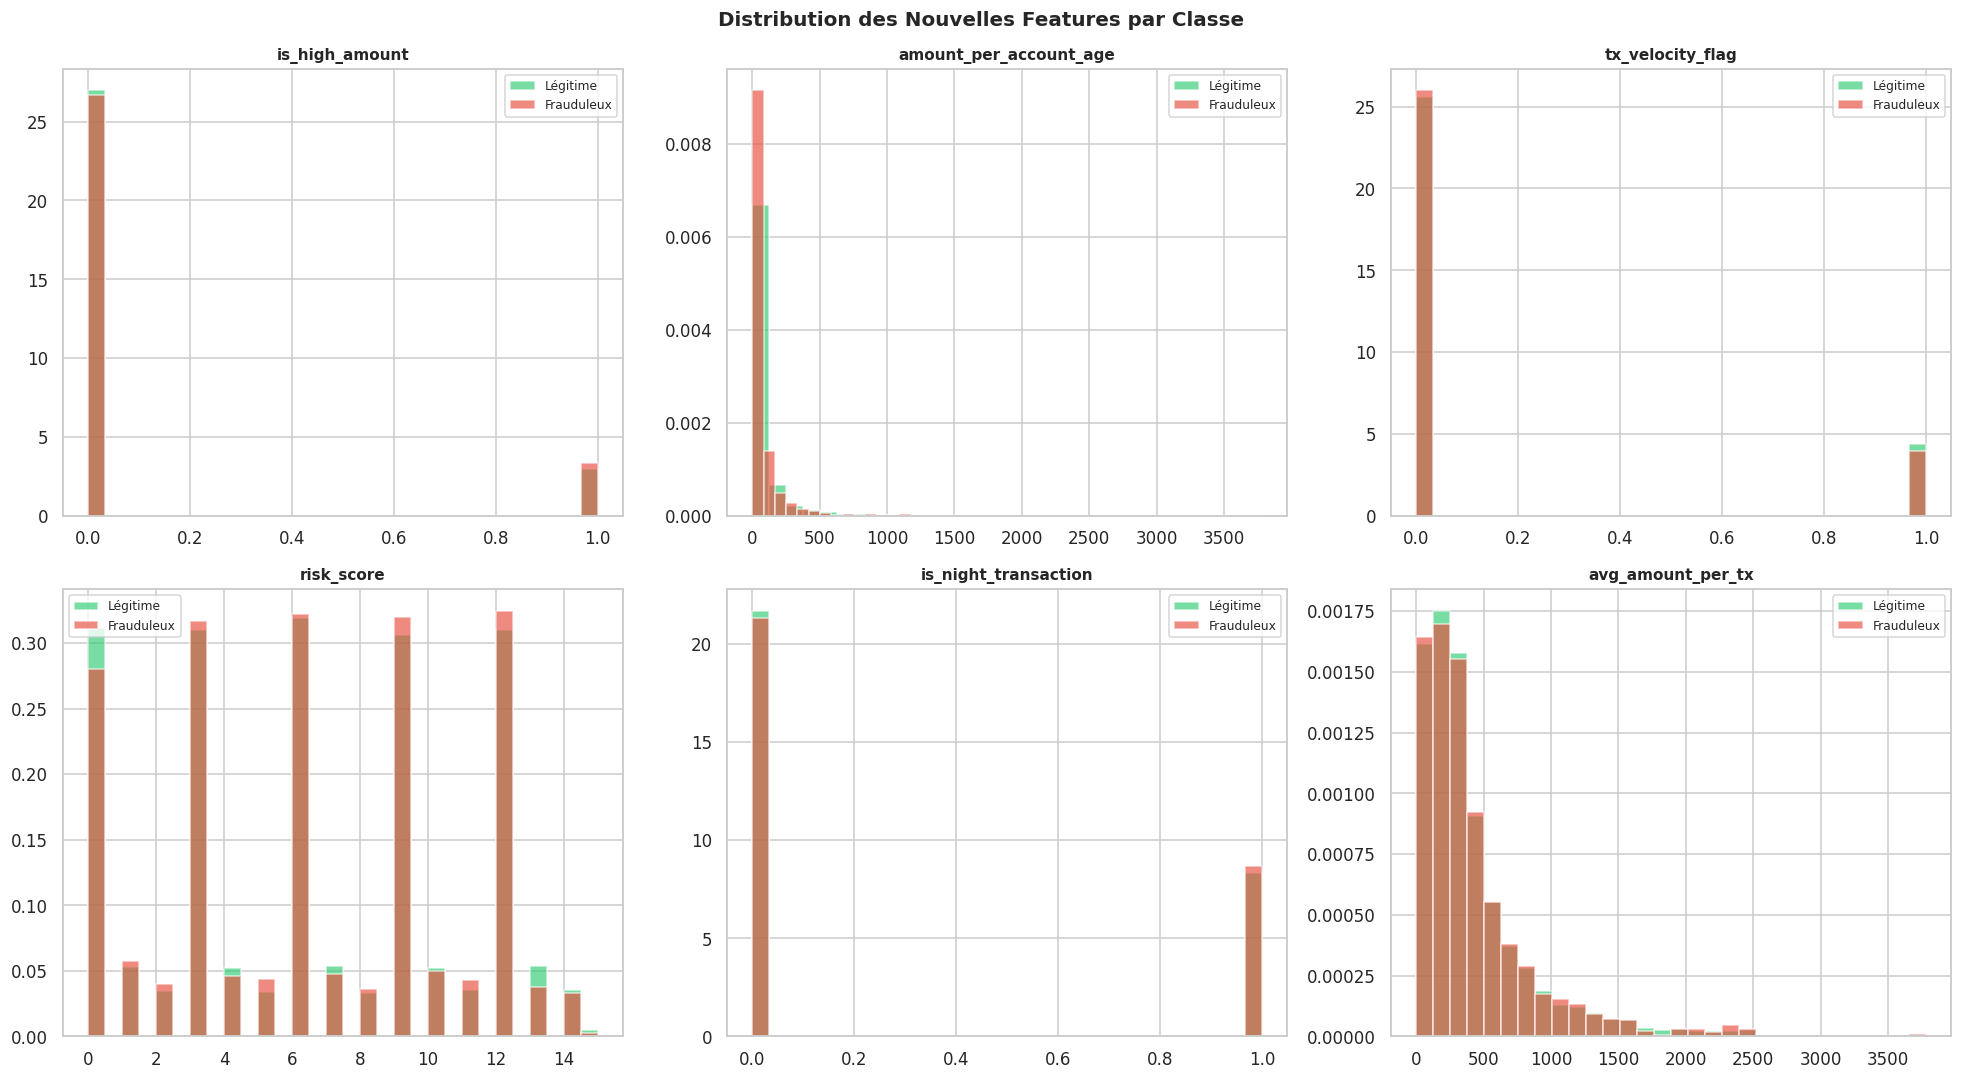

In [246]:
# Visualisation de l'importance des nouvelles features
# On vérifie que nos features métier sont bien discriminantes

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle("Distribution des Nouvelles Features par Classe", fontsize=13, fontweight='bold')

df_fe_viz = X_train_fe[new_features].copy()
df_fe_viz[TARGET] = y_train.values

for i, feat in enumerate(new_features):
    for label, color, name in zip([0, 1], PALETTE, ['Légitime', 'Frauduleux']):
        data = df_fe_viz[df_fe_viz[TARGET] == label][feat]
        axes[i].hist(data, bins=30, alpha=0.65, color=color, label=name, density=True, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figure :importance des new features.png', bbox_inches='tight', dpi=120)
plt.show()

- `is_high_amount` — peu discriminante:  

Les deux barres à 0 (transaction non élevée) sont quasi identiques en hauteur. La barre à 1 montre une légère surreprésentation des fraudes, mais l'écart est faible. Les deux classes ont un comportement similaire vis-à-vis des gros montants.
amount_per_account_age — peu discriminante
Les deux distributions sont presque collées l'une sur l'autre sur toute la plage de valeurs. Légitimes et frauduleux se comportent pareillement. Signal très faible.  

- `tx_velocity_flag` — peu discriminante  

Même constat qu'is_high_amount : les deux classes sont concentrées sur 0, avec un petit excès de fraudes sur 1, mais l'écart est insuffisant pour être utile seul.  

- `risk_score` — la plus intéressante, mais attention
Les barres rouges et vertes alternent sur toutes les valeurs de 0 à 14. Il n'y a pas de séparation nette. Cela suggère que le score composite tel que construit ne crée pas de zone clairement "frauduleuse". Il faudrait retravailler les poids ou les seuils qui le composent.  

- `is_night_transaction` — discriminante !
C'est le graphique le plus parlant. À la valeur 1 (transaction nocturne), la barre rouge (fraude) est nettement plus haute que la verte. Cela signifie que la proportion de fraudes est bien plus grande la nuit. La feature capture un vrai signal métier.  

- `avg_amount_per_tx` — légèrement discriminante
Les fraudes ont une queue de distribution légèrement plus épaisse à droite (valeurs élevées), mais l'écart reste modeste.

Les histogrammes donnent une intuition visuelle, mais pour quantifier la discrimination tester l'approche suivante avec :  

L'Information Mutuelle (mutual_info_classif de sklearn)  mesure la dépendance statistique même non-linéaire, très adapté aux variables binaires

In [247]:
mi = mutual_info_classif(X_train_fe[new_features], y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': new_features, 'Mutual Info': mi})
print(mi_df.sort_values('Mutual Info', ascending=False))

                  Feature  Mutual Info
5       avg_amount_per_tx     0.001779
2        tx_velocity_flag     0.000705
4    is_night_transaction     0.000132
0          is_high_amount     0.000105
1  amount_per_account_age     0.000000
3              risk_score     0.000000


In [248]:
# Corrélation des nouvelles features avec la cible 
fe_analysis = X_train_fe[new_features].copy()
fe_analysis[TARGET] = y_train.values

print("CORRÉLATION DES NOUVELLES FEATURES AVEC LA CIBLE :")
print("-" * 50)
corrs_fe = fe_analysis.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
for feat, val in corrs_fe.items():
    bar = "█" * max(1, int(abs(val) * 60))
    sign = "+" if val > 0 else "-"
    print(f"  {feat:30s} {sign}{abs(val):.3f}  {bar}")

print("risk_score et Previous_Fraudulent_Transactions = features les plus discriminantes")

CORRÉLATION DES NOUVELLES FEATURES AVEC LA CIBLE :
--------------------------------------------------
  tx_velocity_flag               -0.008  █
  is_high_amount                 +0.008  █
  is_night_transaction           +0.006  █
  avg_amount_per_tx              +0.005  █
  amount_per_account_age         -0.004  █
  risk_score                     +0.003  █
risk_score et Previous_Fraudulent_Transactions = features les plus discriminantes


## 6. Gestion du Déséquilibre de Classes

Avec **seulement ~5% de fraudes**, un modèle naïf qui prédit "tout légitime" aurait 95% d'accuracy , mais ce serait totalement inutile en production !

**Stratégies disponibles :**
1. `class_weight='balanced'` → pénalise plus les erreurs sur la classe minoritaire
2. **SMOTE** → génère synthétiquement des exemples de la classe minoritaire
3. Ajustement du seuil de classification (threshold tuning)


In [249]:
# Démonstration du problème du modèle naïf 
naive_preds = np.zeros(len(y_test))  # Prédit tout légitime

print("    MODÈLE NAÏF (tout prédit = légitime) :")
print(f"   Accuracy  : {accuracy_score(y_test, naive_preds)*100:.1f}%  ← TROMPEUSE !")
print(f"   Recall    : {recall_score(y_test, naive_preds)*100:.1f}%  ← DÉSASTREUX")
print(f"   Precision : {precision_score(y_test, naive_preds, zero_division=0)*100:.1f}%")
print(f"   F1-Score  : {f1_score(y_test, naive_preds)*100:.1f}%")
print()
print("C'est pourquoi on privilégie F1-Score, AUC-ROC et Recall en contexte de fraude")
print("En détection de fraude, le RECALL est critique : manquer une fraude coûte cher")

    MODÈLE NAÏF (tout prédit = légitime) :
   Accuracy  : 95.1%  ← TROMPEUSE !
   Recall    : 0.0%  ← DÉSASTREUX
   Precision : 0.0%
   F1-Score  : 0.0%

C'est pourquoi on privilégie F1-Score, AUC-ROC et Recall en contexte de fraude
En détection de fraude, le RECALL est critique : manquer une fraude coûte cher


    SMOTE appliqué :
   Avant SMOTE → {0: 38792, 1: 2008}
   Après SMOTE → {0: 38792, 1: 17456}


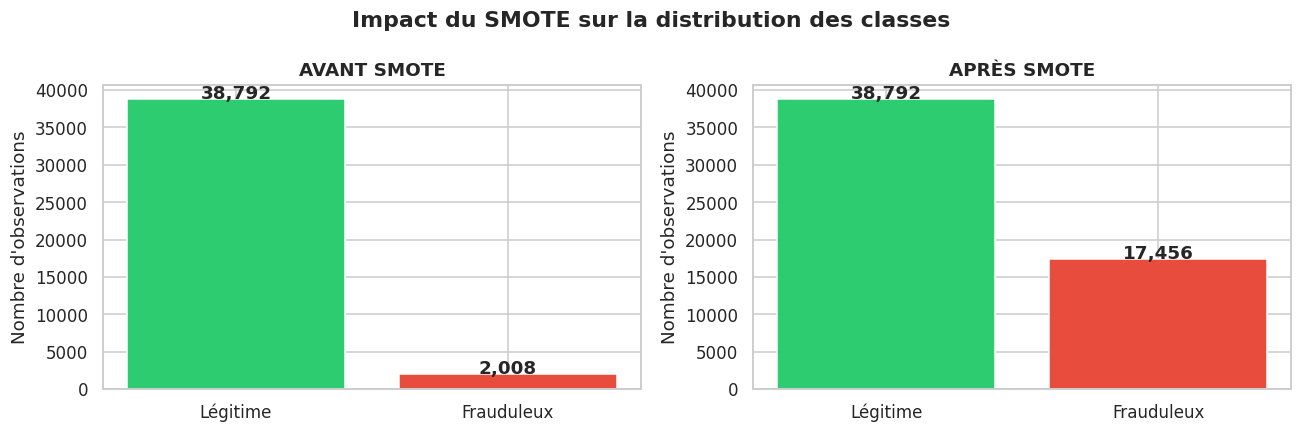

In [250]:
# Application SMOTE si disponible
if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.45)
    X_train_res, y_train_res = smote.fit_resample(X_train_fe, y_train)
    
    print("    SMOTE appliqué :")
    print(f"   Avant SMOTE → {y_train.value_counts().to_dict()}")
    print(f"   Après SMOTE → {pd.Series(y_train_res).value_counts().to_dict()}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, y_data, title in zip(axes, [y_train, y_train_res],['AVANT SMOTE', 'APRÈS SMOTE']):
        counts = pd.Series(y_data).value_counts()
        ax.bar(['Légitime', 'Frauduleux'], counts.values, color=PALETTE, edgecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel("Nombre d'observations")
        for i, v in enumerate(counts.values):
            ax.text(i, v + 20, f"{v:,}", ha='center', fontweight='bold')
    plt.suptitle("Impact du SMOTE sur la distribution des classes", fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_smote.png', bbox_inches='tight', dpi=120)
    plt.show()
else:
    # Sans SMOTE : on utilisera class_weight='balanced'
    X_train_res, y_train_res = X_train_fe, y_train
    print("  SMOTE non disponible → class_weight='balanced' sera utilisé dans les modèles")


## 7. Fonctions Utilitaires d'Évaluation

On centralise l'évaluation dans une fonction réutilisable pour comparer tous nos éventuels modèles de manière équitable.

In [251]:
# Fonction d'évaluation complète
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name="Modèle", threshold=0.5):
    """
    Évalue un modèle de classification binaire avec toutes les métriques 
    pertinentes pour la détection de fraude.
    Returns:
        dict: dictionnaire de toutes les métriques
    """
    # Prédictions
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    # Métriques
    metrics = {
        'model'         : model_name,
        'accuracy'      : accuracy_score(y_te, y_pred),
        'precision'     : precision_score(y_te, y_pred, zero_division=0),
        'recall'        : recall_score(y_te, y_pred),
        'f1'            : f1_score(y_te, y_pred),
        'auc_roc'       : roc_auc_score(y_te, y_prob),
        'auc_pr'        : average_precision_score(y_te, y_prob),
        'threshold'     : threshold,
    }
    
    # Affichage
    print(f"\n{'='*60}")
    print(f"  {model_name.upper()}")
    print(f"{'='*60}")
    print(f"  Threshold utilisé : {threshold:.2f}")
    print(f"  Accuracy          : {metrics['accuracy']*100:6.2f}%")
    print(f"  Precision         : {metrics['precision']*100:6.2f}%")
    print(f"  Recall (Sensib.)  : {metrics['recall']*100:6.2f}%  ← critique en fraude")
    print(f"  F1-Score          : {metrics['f1']*100:6.2f}%")
    print(f"  AUC-ROC           : {metrics['auc_roc']:.4f}")
    print(f"  AUC-PR            : {metrics['auc_pr']:.4f}  ← référence principale")
    
    # Rapport de classification
    print(f"Rapport de Classification :")
    print(classification_report(y_te, y_pred, target_names=['Légitime', 'Frauduleux'],digits=3))
    
    # Matrice de confusion
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Légitime', 'Frauduleux'])
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f"Matrice de Confusion\n{model_name}", fontweight='bold')
    
    # Interprétation métier de la matrice
    tn, fp, fn, tp = cm.ravel()
    axes[1].axis('off')
    interpretation = f"""
  INTERPRÉTATION MÉTIER
  ─────────────────────────────────────
    Vrais Positifs (TP)  : {tp:>5,}
     Fraudes détectées → ALERTE ENVOYÉE

    Vrais Négatifs (TN)  : {tn:>5,}
     Légitimes confirmées → AUTORISÉE

    Faux Positifs (FP)   : {fp:>5,}
     Légitimes bloquées → FRICTION CLIENT
     Coût : expérience dégradée

    Faux Négatifs (FN)   : {fn:>5,}
     Fraudes manquées → PERTE FINANCIÈRE
     Coût : élevé (remboursement)
     
  Taux de détection       : {tp/(tp+fn)*100:.1f}%
  Taux de fausse alarme   : {fp/(fp+tn)*100:.1f}%
"""
    axes[1].text(
        0.05, 0.5, interpretation, transform=axes[1].transAxes,
        fontsize=10, va='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
    )
    
    plt.tight_layout()
    plt.savefig(f'fig_confusion_{model_name.replace(" ", "_")}.png', bbox_inches='tight', dpi=110)
    plt.show()
    
    return metrics


# Dictionnaire pour stocker tous les résultats
all_results = {}
print("Fonction d'évaluation définie et prête")


Fonction d'évaluation définie et prête


## 8. Decision Tree — Premier Modèle (Sans Tuning)

On commence par un arbre de décision **sans contraintes** pour observer son comportement naturel et diagnostiquer le sur-apprentissage (overfitting).

L'arbre de décision est particulièrement adapté à ce problème car :
- Il capture des **interactions non-linéaires** que d'autres algorithmes comme Logistic regression ne capture pas
- Il est **directement interprétable** — on peut extraire des règles métier
- Il gère naturellement les variables catégorielles encodées

In [252]:
dt_raw = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight='balanced'   # Toujours important avec données déséquilibrées
)
dt_raw.fit(X_train_fe, y_train)

print("    Arbre de décision entraîné (sans contraintes)")
print(f"   Profondeur maximale atteinte : {dt_raw.get_depth()}")
print(f"   Nombre de feuilles           : {dt_raw.get_n_leaves()}")
print(f"   Nombre de nœuds              : {dt_raw.tree_.node_count}")


    Arbre de décision entraîné (sans contraintes)
   Profondeur maximale atteinte : 48
   Nombre de feuilles           : 4191
   Nombre de nœuds              : 8381


In [254]:
# Diagnostic : Train vs Test
train_score = dt_raw.score(X_train_fe, y_train)
test_score  = dt_raw.score(X_test_fe, y_test)

train_f1 = f1_score(y_train, dt_raw.predict(X_train_fe))
test_f1  = f1_score(y_test, dt_raw.predict(X_test_fe))

print("DIAGNOSTIC OVERFITTING")
print("-" * 40)
print(f"  Accuracy  TRAIN : {train_score*100:.2f}%")
print(f"  Accuracy  TEST  : {test_score*100:.2f}%")
print(f"  F1-Score  TRAIN : {train_f1*100:.2f}%")
print(f"  F1-Score  TEST  : {test_f1*100:.2f}%")
gap = train_f1 - test_f1
print()
print(f"Écart Train-Test (F1) : {gap*100:.2f}%")
if gap > 0.1:
    print("     OVERFITTING DÉTECTÉ — L'arbre mémorise le train set")
    print("     Solution : réduire la profondeur, augmenter min_samples_leaf")
else:
    print("     Pas de sur-apprentissage détecté")


DIAGNOSTIC OVERFITTING
----------------------------------------
  Accuracy  TRAIN : 100.00%
  Accuracy  TEST  : 90.55%
  F1-Score  TRAIN : 100.00%
  F1-Score  TEST  : 5.86%

Écart Train-Test (F1) : 94.14%
     OVERFITTING DÉTECTÉ — L'arbre mémorise le train set
     Solution : réduire la profondeur, augmenter min_samples_leaf


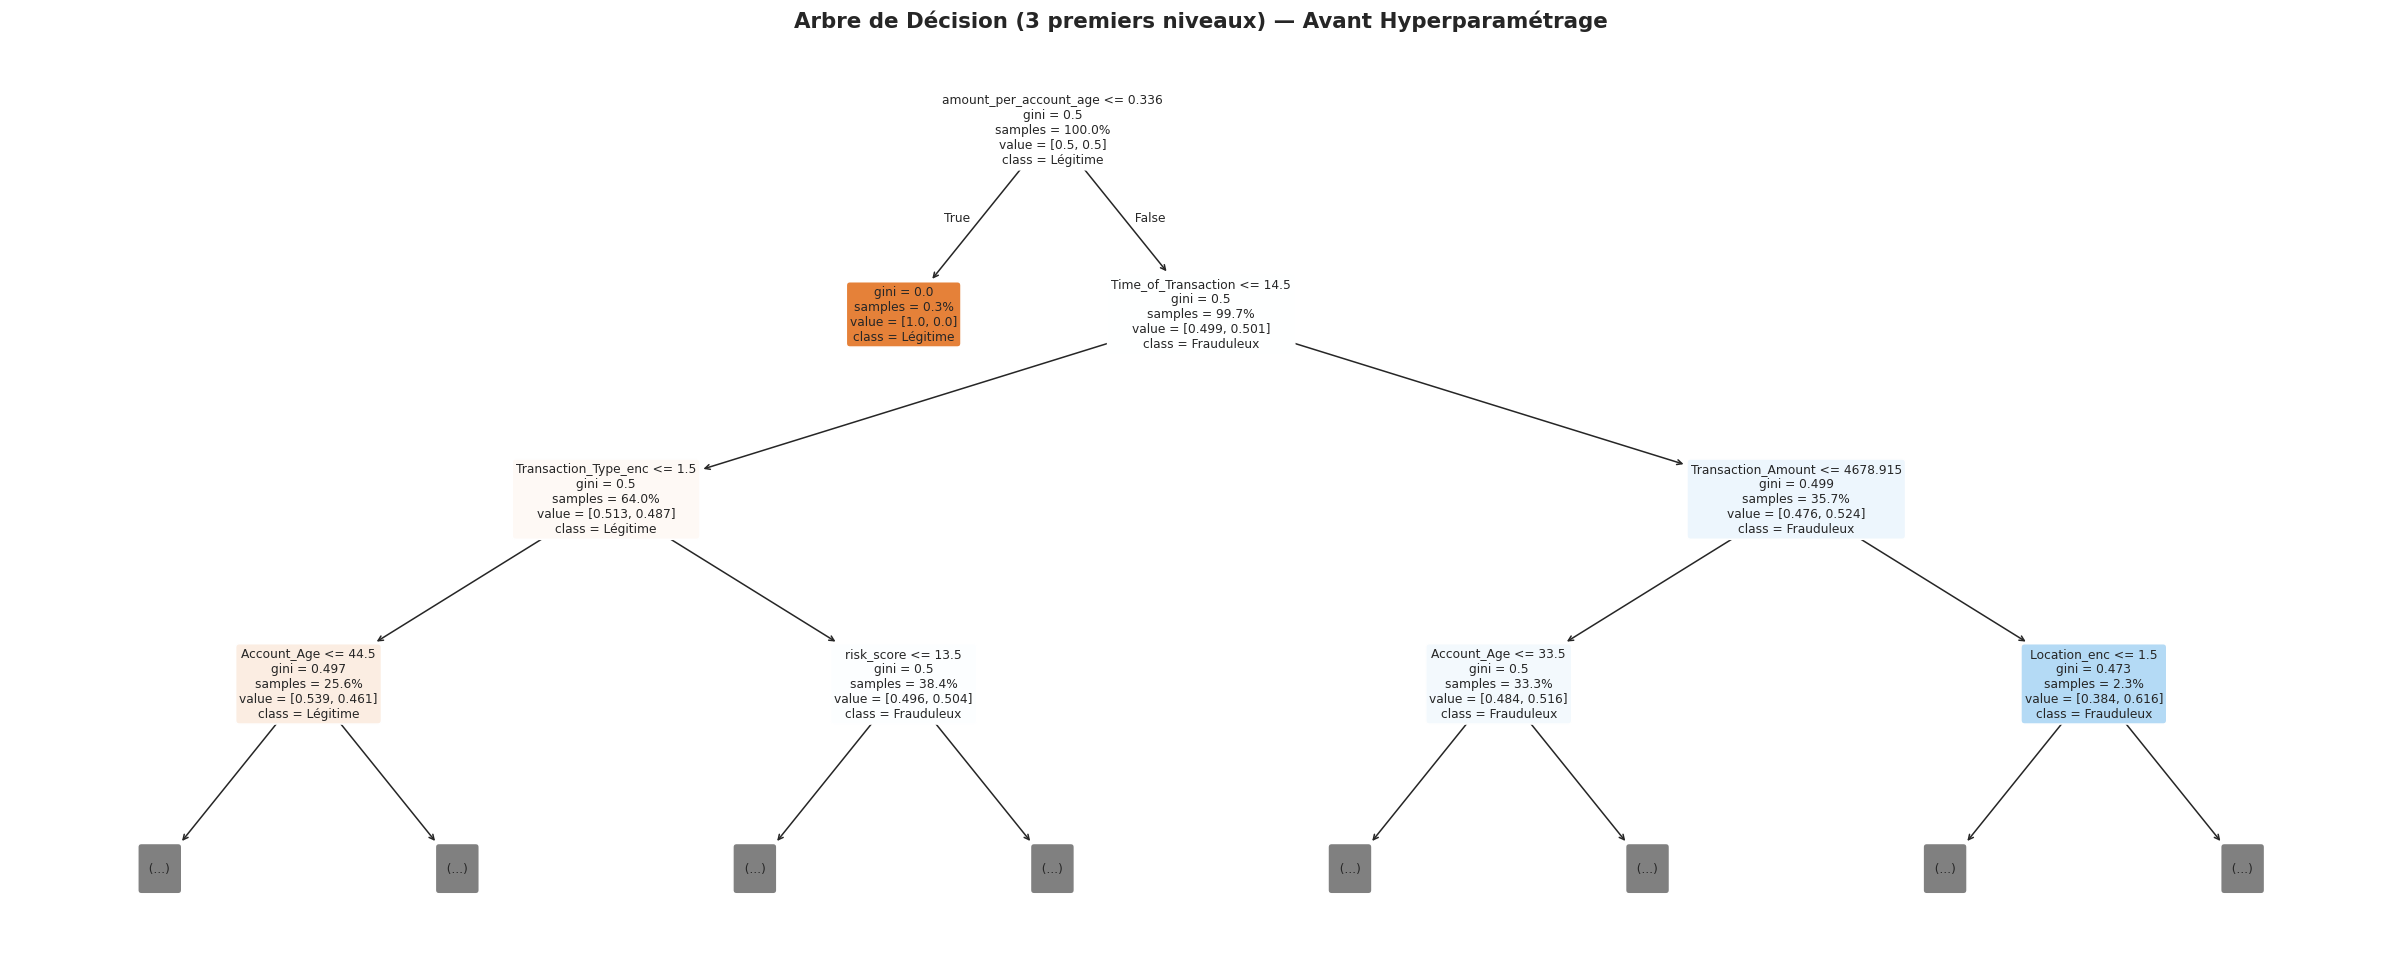

Seuls les 3 premiers niveaux sont affichés: l'arbre complet est trop profond


In [255]:
# Visualisation de l'arbre tronqué à profondeur 3 pour la lisibilité
plt.figure(figsize=(22, 9))
plot_tree(
    dt_raw, 
    max_depth=3,
    feature_names=X_train_fe.columns.tolist(),
    class_names=['Légitime', 'Frauduleux'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    fontsize=8
)
plt.title("Arbre de Décision (3 premiers niveaux) — Avant Hyperparamétrage", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_tree_raw.png', bbox_inches='tight', dpi=100)
plt.show()
print("Seuls les 3 premiers niveaux sont affichés: l'arbre complet est trop profond")


  DECISION TREE BRUT
  Threshold utilisé : 0.50
  Accuracy          :  90.55%
  Precision         :   5.75%
  Recall (Sensib.)  :   5.98%  ← critique en fraude
  F1-Score          :   5.86%
  AUC-ROC           : 0.5045
  AUC-PR            : 0.0497  ← référence principale
Rapport de Classification :
              precision    recall  f1-score   support

    Légitime      0.951     0.949     0.950      9698
  Frauduleux      0.057     0.060     0.059       502

    accuracy                          0.905     10200
   macro avg      0.504     0.505     0.504     10200
weighted avg      0.907     0.905     0.906     10200



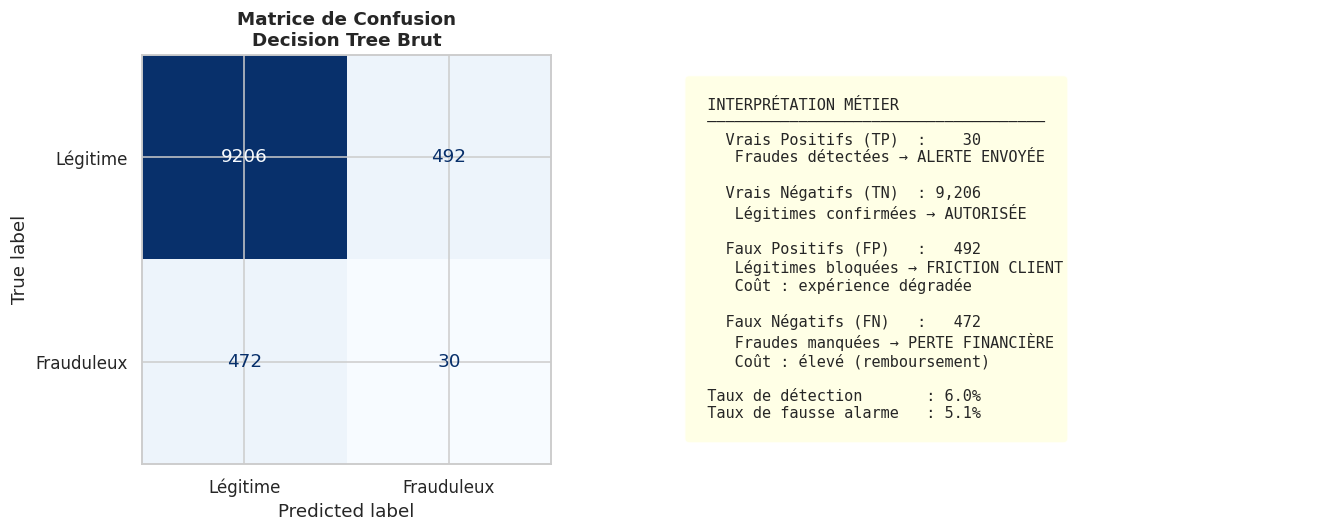

In [256]:
# Évaluation du Decision Tree brut
results_dt_raw = evaluate_model(dt_raw, X_train_fe, y_train, X_test_fe, y_test,model_name="Decision Tree Brut")
all_results['DT_raw'] = results_dt_raw

## 9. Hyperparamétrage du Decision Tree

L'hyperparamétrage est l'art de **trouver les meilleurs paramètres** pour notre modèle. On va explorer deux approches :

1. **GridSearchCV** — Recherche exhaustive sur une grille définie
2. **RandomizedSearchCV** — Recherche aléatoire sur un espace plus large

**Principaux hyperparamètres du DecisionTreeClassifier :**

| Hyperparamètre | Rôle | Impact sur overfitting |
|---|---|---|
| `max_depth` | Profondeur maximale de l'arbre | ↑ = plus d'overfitting |
| `min_samples_split` | Nb min d'échantillons pour splitter | ↑ = moins d'overfitting |
| `min_samples_leaf` | Nb min d'échantillons en feuille | ↑ = moins d'overfitting |
| `max_features` | Nb de features testées à chaque split | Variance/biais |
| `criterion` | Mesure d'impureté (gini/entropy) | Qualité des splits |
| `class_weight` | Pondération des classes | Gestion déséquilibre |

ANALYSE DE max_depth SUR LES PERFORMANCES .. 
-------------------------------------------------------


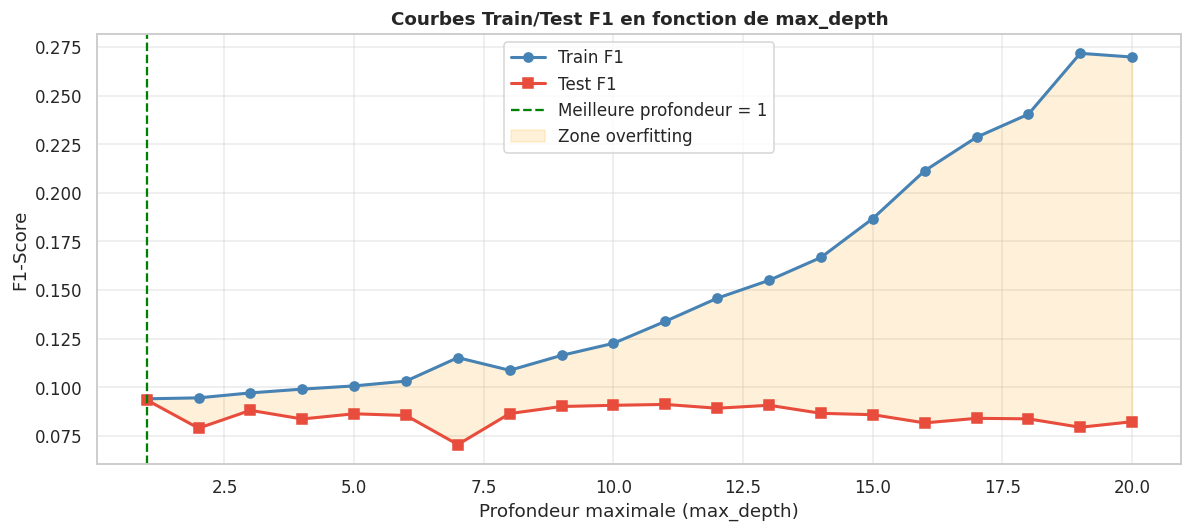


Meilleure profondeur sur test : max_depth = 1
F1 test correspondant         : 9.35%


In [257]:
# Analyse préalable : impact de max_depth 
print("ANALYSE DE max_depth SUR LES PERFORMANCES .. ")
print("-" * 55)

depths = range(1, 21)
train_f1s, test_f1s = [], []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for d in depths:
    dt_tmp = DecisionTreeClassifier(
        max_depth=d, 
        class_weight= 'balanced',
        random_state=RANDOM_STATE
    )
    dt_tmp.fit(X_train_fe, y_train)
    train_f1s.append(f1_score(y_train, dt_tmp.predict(X_train_fe)))
    test_f1s.append(f1_score(y_test, dt_tmp.predict(X_test_fe)))

plt.figure(figsize=(11, 5))
plt.plot(depths, train_f1s, 'o-', color='steelblue', linewidth=2, label='Train F1')
plt.plot(depths, test_f1s,  's-', color=PALETTE[1], linewidth=2, label='Test F1')
best_depth = depths[np.argmax(test_f1s)]
plt.axvline(best_depth, color='green', linestyle='--', linewidth=1.5, label=f'Meilleure profondeur = {best_depth}')
plt.fill_between(depths, train_f1s, test_f1s, alpha=0.15, color='orange', label='Zone overfitting')
plt.xlabel("Profondeur maximale (max_depth)")
plt.ylabel("F1-Score")
plt.title("Courbes Train/Test F1 en fonction de max_depth", fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig_depth_analysis.png', bbox_inches='tight', dpi=110)
plt.show()

print()
print(f"Meilleure profondeur sur test : max_depth = {best_depth}")
print(f"F1 test correspondant         : {max(test_f1s)*100:.2f}%")

In [258]:
# GridSearchCV — Recherche exhaustive
print("GRIDSEARCHCV en cours... ")
print("-" * 45)

param_grid = {
    'max_depth'          : [3, 5, 7, 10, 15],
    'min_samples_split'  : [2, 10, 20, 50],
    'min_samples_leaf'   : [1, 5, 10, 20],
    'criterion'          : ['gini', 'entropy'],
    'class_weight'       : ['balanced']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator   = DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid  = param_grid,
    cv          = cv_strategy,
    scoring     = 'f1',          # Optimise le F1 (adapté au déséquilibre)
    n_jobs      = -1,            # Utilise tous les cœurs disponibles
    verbose     = 1,
    return_train_score=True
)

grid_search.fit(X_train_fe, y_train)

print(f"GridSearchCV terminé !")
print(f"Combinaisons testées : {len(grid_search.cv_results_['mean_test_score'])}")
print(f"Meilleur score CV    : {grid_search.best_score_*100:.3f}% (F1)")
print(f"MEILLEURS HYPERPARAMÈTRES :")
for k, v in grid_search.best_params_.items():
    print(f"     {k:25s} = {v}")

GRIDSEARCHCV en cours... 
---------------------------------------------
Fitting 5 folds for each of 160 candidates, totalling 800 fits
GridSearchCV terminé !
Combinaisons testées : 160
Meilleur score CV    : 9.266% (F1)
MEILLEURS HYPERPARAMÈTRES :
     class_weight              = balanced
     criterion                 = entropy
     max_depth                 = 10
     min_samples_leaf          = 20
     min_samples_split         = 2


In [259]:
from sklearn.metrics import classification_report, confusion_matrix

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_fe) 

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[2866 6832]
 [ 166  336]]
              precision    recall  f1-score   support

           0       0.95      0.30      0.45      9698
           1       0.05      0.67      0.09       502

    accuracy                           0.31     10200
   macro avg       0.50      0.48      0.27     10200
weighted avg       0.90      0.31      0.43     10200



In [260]:
# Analyse des résultats GridSearch 
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_top = cv_results.nlargest(15, 'mean_test_score')[
    ['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf',
     'param_criterion', 'mean_test_score', 'std_test_score', 'mean_train_score']
].round(4)

print("TOP 15 CONFIGURATIONS GRIDSEACHCV :")
print(cv_results_top.to_string(index=False))


TOP 15 CONFIGURATIONS GRIDSEACHCV :
 param_max_depth  param_min_samples_split  param_min_samples_leaf param_criterion  mean_test_score  std_test_score  mean_train_score
              10                        2                      20         entropy           0.0927          0.0035            0.1131
              10                       10                      20         entropy           0.0927          0.0035            0.1131
              10                       20                      20         entropy           0.0927          0.0035            0.1131
              10                       50                      20         entropy           0.0926          0.0036            0.1131
              10                       20                       5         entropy           0.0925          0.0041            0.1142
              10                        2                       5         entropy           0.0925          0.0043            0.1144
              10                 

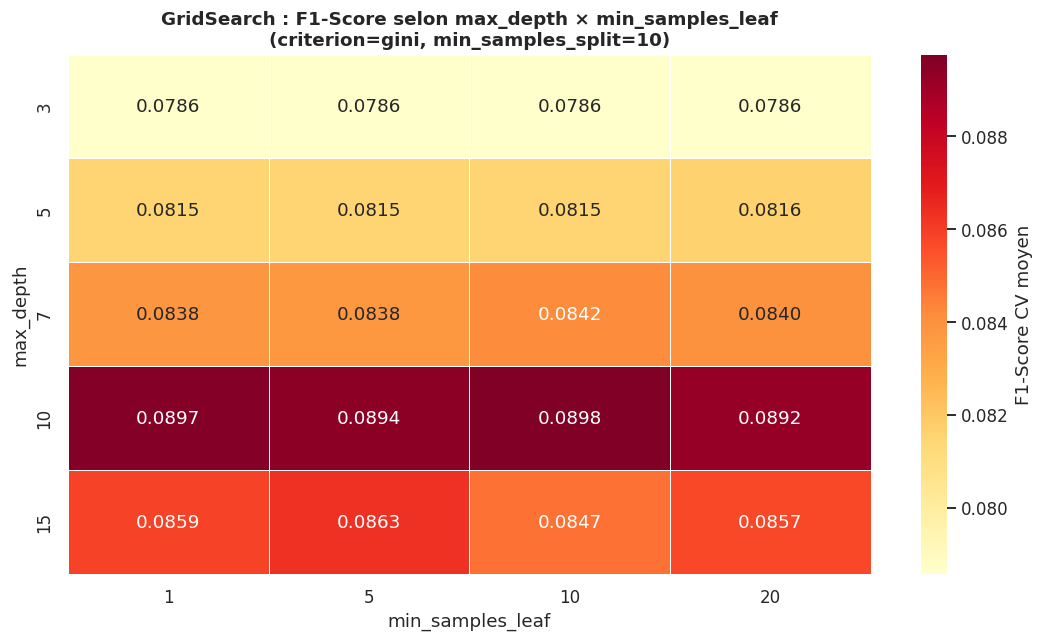

In [261]:
#Heatmap des hyperparamètres 
# Visualisation de l'interaction max_depth × min_samples_leaf
pivot_data = cv_results[
    (cv_results['param_criterion'] == 'gini') &
    (cv_results['param_min_samples_split'] == 10)
].pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_min_samples_leaf'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'F1-Score CV moyen'})
plt.title("GridSearch : F1-Score selon max_depth × min_samples_leaf\n(criterion=gini, min_samples_split=10)", 
          fontweight='bold')
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.tight_layout()
plt.savefig('fig_grid_heatmap.png', bbox_inches='tight', dpi=110)
plt.show()

In [262]:
# RandomizedSearchCV — Exploration plus large 
from scipy.stats import randint, uniform

print("RANDOMIZEDSEARCHCV en cours...")
print("-" * 45)

param_dist = {
    'max_depth'           : randint(3, 25),
    'min_samples_split'   : randint(2, 100),
    'min_samples_leaf'    : randint(1, 50),
    'max_features'        : ['sqrt', 'log2', None, 0.5, 0.7],
    'criterion'           : ['gini', 'entropy', 'log_loss'],
    'max_leaf_nodes'      : [None, 20, 50, 100, 200],
    'class_weight'        : ['balanced'],
    'splitter'            : ['best', 'random'],
}

random_search = RandomizedSearchCV(
    estimator    = DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_distributions = param_dist,
    n_iter       = 200,          # 200 combinaisons aléatoires
    cv           = cv_strategy,
    scoring      = 'f1',
    n_jobs       = -1,
    verbose      = 1,
    random_state = RANDOM_STATE,
    return_train_score=True
)

random_search.fit(X_train_fe, y_train)

print(f"RandomizedSearchCV terminé !")
print(f"Combinaisons testées : 200")
print(f"Meilleur score CV    : {random_search.best_score_*100:.3f}% (F1)")
print(f"MEILLEURS HYPERPARAMÈTRES :")
for k, v in random_search.best_params_.items():
    print(f"     {k:25s} = {v}")

RANDOMIZEDSEARCHCV en cours...
---------------------------------------------
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
RandomizedSearchCV terminé !
Combinaisons testées : 200
Meilleur score CV    : 9.690% (F1)
MEILLEURS HYPERPARAMÈTRES :
     class_weight              = balanced
     criterion                 = gini
     max_depth                 = 22
     max_features              = None
     max_leaf_nodes            = None
     min_samples_leaf          = 8
     min_samples_split         = 37
     splitter                  = random


In [263]:
# Sélection du meilleur modèle entre Grid et Random Search
best_grid   = grid_search.best_score_
best_random = random_search.best_score_

if best_grid >= best_random:
    best_params = grid_search.best_params_
    print(f"GridSearchCV gagne : {best_grid*100:.3f}% vs {best_random*100:.3f}%")
else:
    best_params = random_search.best_params_
    print(f"RandomizedSearchCV gagne : {best_random*100:.3f}% vs {best_grid*100:.3f}%")

print(f"Paramètres retenus : {best_params}")


RandomizedSearchCV gagne : 9.690% vs 9.266%
Paramètres retenus : {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 22, 'max_features': None, 'max_leaf_nodes': None, 'min_samples_leaf': 8, 'min_samples_split': 37, 'splitter': 'random'}


In [264]:
# Entraînement du Decision Tree final optimisé 
dt_optimized = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
dt_optimized.fit(X_train_fe, y_train)

print("    Decision Tree OPTIMISÉ entraîné")
print(f"   Profondeur effective : {dt_optimized.get_depth()}")
print(f"   Nombre de feuilles   : {dt_optimized.get_n_leaves()}")


    Decision Tree OPTIMISÉ entraîné
   Profondeur effective : 22
   Nombre de feuilles   : 1455



  DECISION TREE OPTIMISÉ
  Threshold utilisé : 0.50
  Accuracy          :  63.15%
  Precision         :   4.83%
  Recall (Sensib.)  :  34.66%  ← critique en fraude
  F1-Score          :   8.47%
  AUC-ROC           : 0.4958
  AUC-PR            : 0.0493  ← référence principale
Rapport de Classification :
              precision    recall  f1-score   support

    Légitime      0.950     0.646     0.769      9698
  Frauduleux      0.048     0.347     0.085       502

    accuracy                          0.631     10200
   macro avg      0.499     0.496     0.427     10200
weighted avg      0.906     0.631     0.736     10200



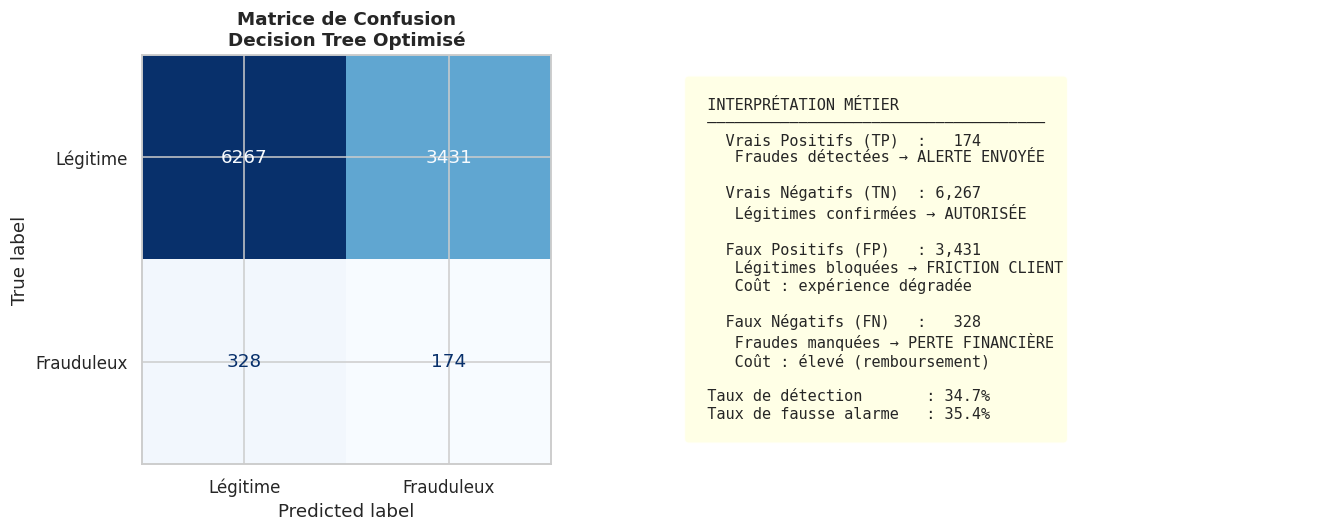

In [265]:
# Évaluation complète du Decision Tree optimisé 
results_dt_opt = evaluate_model(dt_optimized, X_train_fe, y_train, X_test_fe, y_test, model_name="Decision Tree Optimisé")
all_results['DT_optimized'] = results_dt_opt

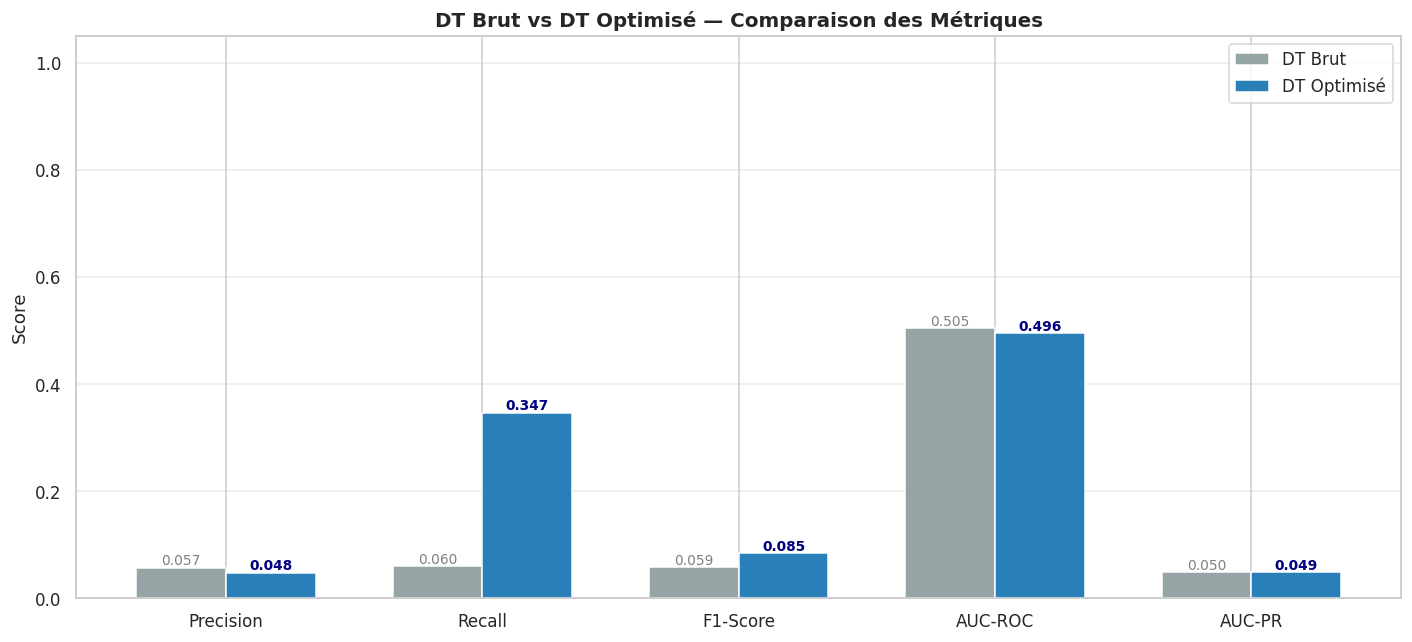

GAINS APPORTÉS PAR L'OPTIMISATION :
   Precision    : -0.92%
   Recall       : +28.69%
   F1-Score     : +2.61%
   AUC-ROC      : -0.88%
   AUC-PR       : -0.04%


In [266]:
# Comparaison DT Brut vs DT Optimisé
metrics_to_compare = ['precision', 'recall', 'f1', 'auc_roc', 'auc_pr']
labels = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']

raw_vals = [all_results['DT_raw'][m] for m in metrics_to_compare]
opt_vals = [all_results['DT_optimized'][m] for m in metrics_to_compare]

x = np.arange(len(metrics_to_compare))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, raw_vals, width, label='DT Brut', color='#95a5a6', edgecolor='white')
bars2 = ax.bar(x + width/2, opt_vals, width, label='DT Optimisé', color='#2980b9', edgecolor='white')

for bar, val in zip(bars1, raw_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,f'{val:.3f}', ha='center', fontsize=9, color='gray')
for bar, val in zip(bars2, opt_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,f'{val:.3f}', ha='center', fontsize=9, fontweight='bold', color='navy')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Score")
ax.set_title("DT Brut vs DT Optimisé — Comparaison des Métriques", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig_dt_comparison.png', bbox_inches='tight', dpi=110)
plt.show()

# Gains
print("GAINS APPORTÉS PAR L'OPTIMISATION :")
for metric, label in zip(metrics_to_compare, labels):
    gain = (all_results['DT_optimized'][metric] - all_results['DT_raw'][metric]) * 100
    sign = "+" if gain >= 0 else ""
    print(f"   {label:12s} : {sign}{gain:.2f}%")

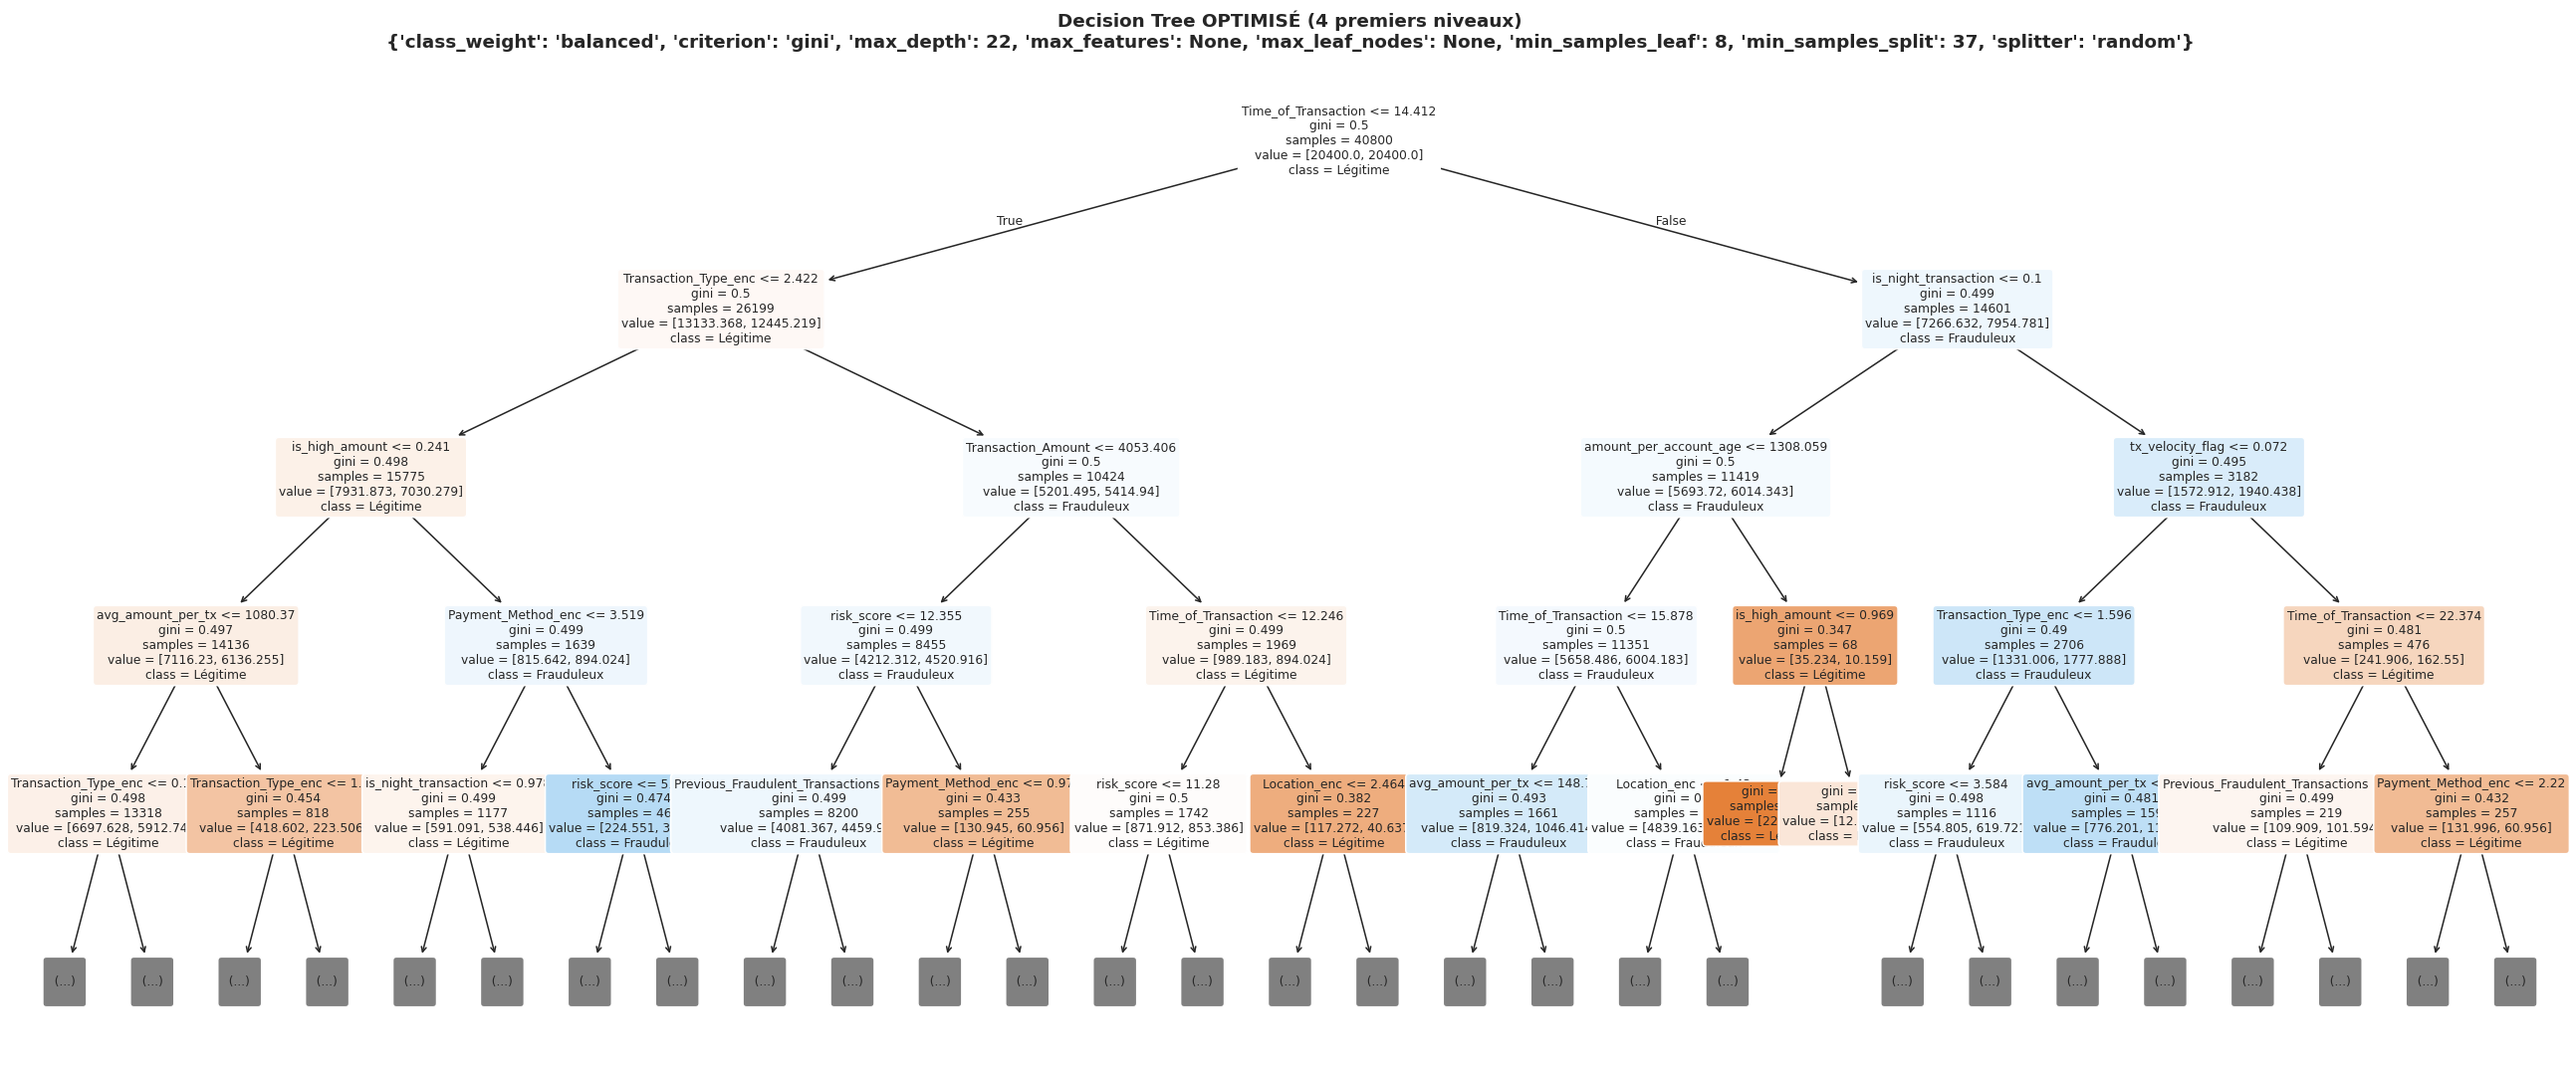

In [267]:
# Visualisation de l'arbre optimisé 
plt.figure(figsize=(24, 10))
plot_tree(
    dt_optimized, 
    max_depth=4,
    feature_names=X_train_fe.columns.tolist(),
    class_names=['Légitime', 'Frauduleux'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=8
)
plt.title(f"Decision Tree OPTIMISÉ (4 premiers niveaux)\n{best_params}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_tree_optimized.png', bbox_inches='tight', dpi=100)
plt.show()

=====Calcul des courbes d'apprentissage=====


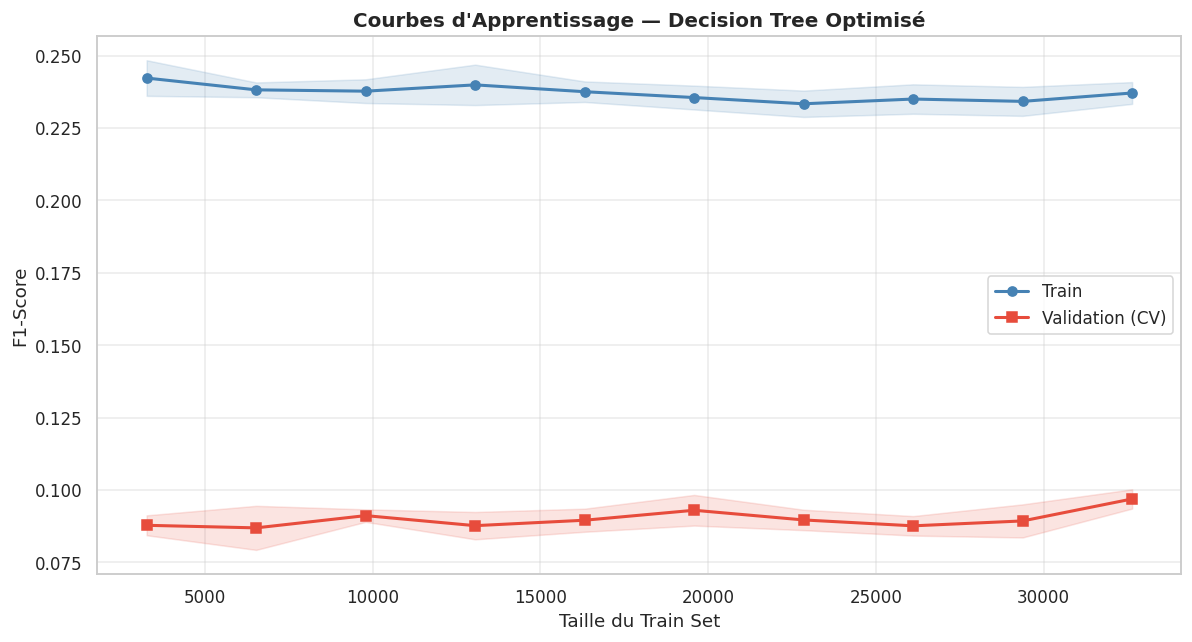


  Écart final Train-Val : 0.1402
  Léger overfitting — acceptable en production


In [268]:
# Learning Curves — Détection du régime d'apprentissage 
print("=====Calcul des courbes d'apprentissage=====")

train_sizes, train_scores, val_scores = learning_curve(
    dt_optimized, X_train_fe, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv_strategy, scoring='f1', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='steelblue', label='Train', linewidth=2)
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_scores.mean(axis=1), 's-', color=PALETTE[1], label='Validation (CV)', linewidth=2)
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1), val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color=PALETTE[1])

ax.set_xlabel("Taille du Train Set", fontsize=12)
ax.set_ylabel("F1-Score", fontsize=12)
ax.set_title("Courbes d'Apprentissage — Decision Tree Optimisé", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig_learning_curves.png', bbox_inches='tight', dpi=110)
plt.show()

# Interprétation
final_gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f"\n  Écart final Train-Val : {final_gap:.4f}")
if final_gap < 0.05:
    print("  Bon équilibre biais-variance — le modèle généralise bien")
elif final_gap < 0.15:
    print("  Léger overfitting — acceptable en production")
else:
    print("  Overfitting significatif — réduire la complexité du modèle")

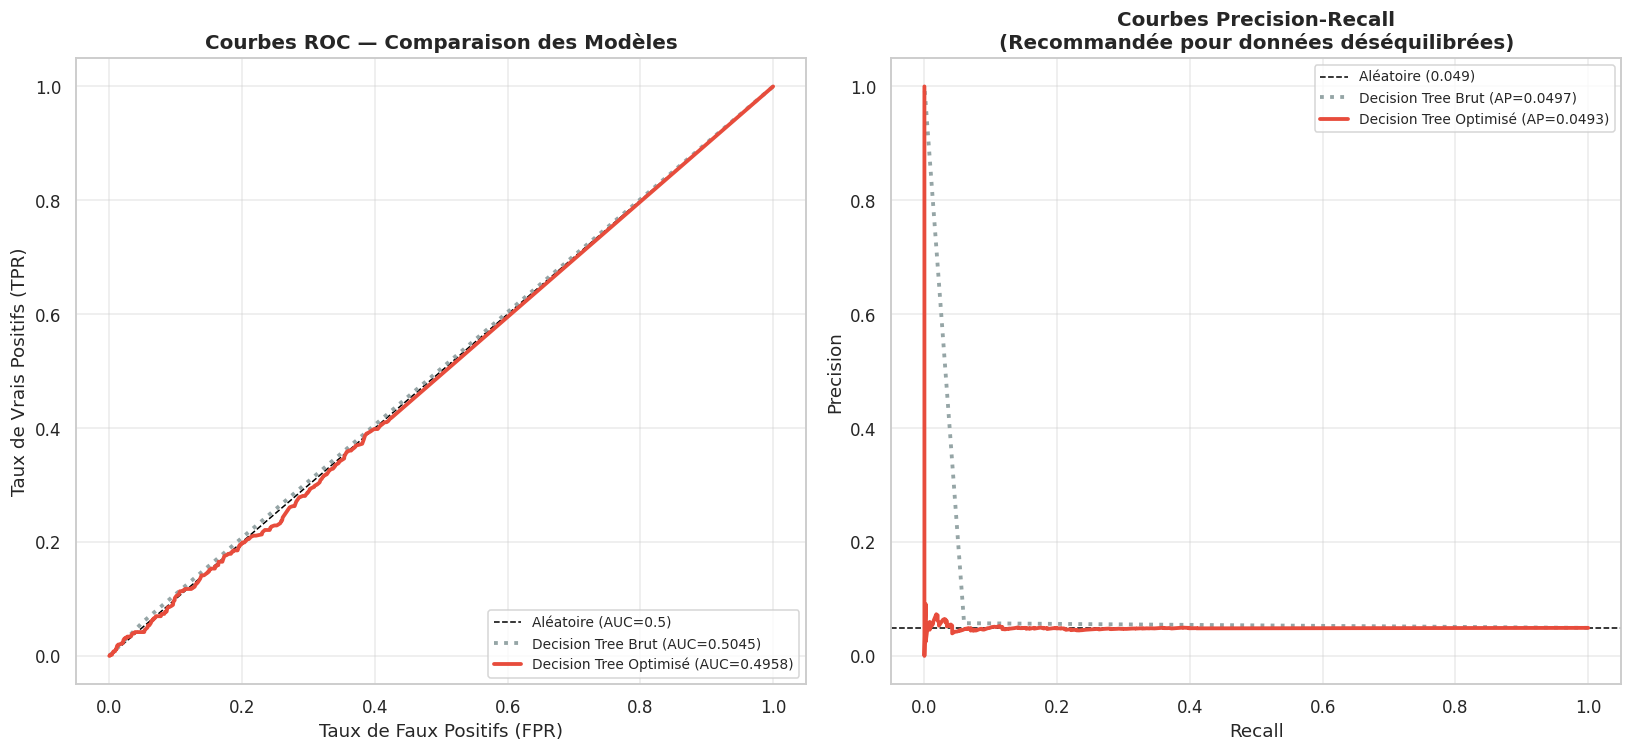

In [ ]:
# Courbes ROC comparatives
models_to_compare = [
    (dt_raw,       X_test_fe,     'Decision Tree Brut',    '#95a5a6', ':'),
    (dt_optimized, X_test_fe,     'Decision Tree Optimisé','#e74c3c', '-'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ROC Curve
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC=0.5)')
for model, X_te, name, color, ls in models_to_compare:
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, linewidth=2.5, color=color, linestyle=ls,
                 label=f"{name} (AUC={auc:.4f})")

axes[0].set_xlabel("Taux de Faux Positifs (FPR)", fontsize=12)
axes[0].set_ylabel("Taux de Vrais Positifs (TPR)", fontsize=12)
axes[0].set_title("Courbes ROC — Comparaison des Modèles", fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.4)

# Precision-Recall Curve 
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='k', linestyle='--', linewidth=1, 
                label=f'Aléatoire ({baseline_pr:.3f})')
for model, X_te, name, color, ls in models_to_compare:
    y_prob = model.predict_proba(X_te)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, linewidth=2.5, color=color, linestyle=ls,
                 label=f"{name} (AP={ap:.4f})")

axes[1].set_xlabel("Recall", fontsize=12)
axes[1].set_ylabel("Precision", fontsize=12)
axes[1].set_title("Courbes Precision-Recall", 
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig_roc_pr_curves.png', bbox_inches='tight', dpi=120)
plt.show()

In [270]:
#Tableau comparatif final
comparison_df = pd.DataFrame([
    {
        'Modèle'   : all_results[k]['model'],
        'Accuracy' : f"{all_results[k]['accuracy']*100:.2f}%",
        'Precision': f"{all_results[k]['precision']*100:.2f}%",
        'Recall'   : f"{all_results[k]['recall']*100:.2f}%",
        'F1-Score' : f"{all_results[k]['f1']*100:.2f}%",
        'AUC-ROC'  : f"{all_results[k]['auc_roc']:.4f}",
        'AUC-PR'   : f"{all_results[k]['auc_pr']:.4f}",
    }
    for k in all_results
])

print("=" * 85)
print(" TABLEAU COMPARATIF FINAL — TOUS LES MODÈLES")
print("=" * 85)
print(comparison_df.to_string(index=False))
print("=" * 85)
print("Métrique prioritaire en fraude : AUC-PR (Precision-Recall)")
print("Pénalise plus les faux négatifs (fraudes non détectées)")

 TABLEAU COMPARATIF FINAL — TOUS LES MODÈLES
                Modèle Accuracy Precision Recall F1-Score AUC-ROC AUC-PR
    Decision Tree Brut   90.55%     5.75%  5.98%    5.86%  0.5045 0.0497
Decision Tree Optimisé   63.15%     4.83% 34.66%    8.47%  0.4958 0.0493
Métrique prioritaire en fraude : AUC-PR (Precision-Recall)
Pénalise plus les faux négatifs (fraudes non détectées)


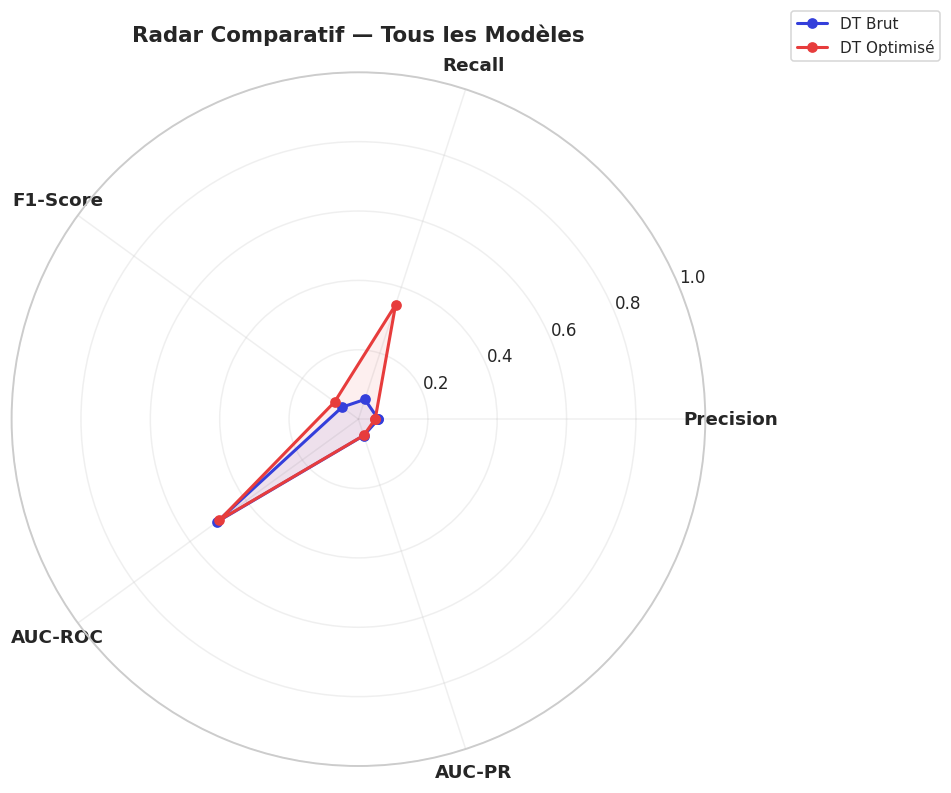

In [271]:
# ─── 12.3 Radar chart comparatif ───
from matplotlib.patches import FancyArrowPatch

categories  = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']
model_vals  = {
    'DT Brut'        : [all_results['DT_raw'][m]      for m in ['precision','recall','f1','auc_roc','auc_pr']],
    'DT Optimisé'    : [all_results['DT_optimized'][m] for m in ['precision','recall','f1','auc_roc','auc_pr']]
}
colors_radar = ["#343fdb", "#e73c3c"]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for (name, vals), color in zip(model_vals.items(), colors_radar):
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles, vals_plot, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title("Radar Comparatif — Tous les Modèles", fontsize=14, 
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_radar_comparison.png', bbox_inches='tight', dpi=110)
plt.show()


## 10.  Interprétabilité — Extraction des Règles Métier

Un modèle ML n'est utile en entreprise que si on peut **expliquer ses décisions**. On va extraire des règles concrètes du Decision Tree optimisé pour que les équipes métier puissent les comprendre et les valider.



In [272]:
# Règles de décision — Top chemins vers "Fraude" 
feature_list = X_train_fe.columns.tolist()
rules_text = export_text(dt_optimized, feature_names=feature_list, max_depth=5)

print("RÈGLES DE DÉCISION — Decision Tree Optimisé")
print("=" * 65)
print("  (Chemins conduisant à la classification FRAUDULEUX)")
print("=" * 65)

# Afficher les 3500 premiers caractères (règles les plus importantes)
print(rules_text[:3500])
if len(rules_text) > 3500:
    print("règles tronquées pour lisibilité ...")

RÈGLES DE DÉCISION — Decision Tree Optimisé
  (Chemins conduisant à la classification FRAUDULEUX)
|--- Time_of_Transaction <= 14.41
|   |--- Transaction_Type_enc <= 2.42
|   |   |--- is_high_amount <= 0.24
|   |   |   |--- avg_amount_per_tx <= 1080.37
|   |   |   |   |--- Transaction_Type_enc <= 0.11
|   |   |   |   |   |--- tx_velocity_flag <= 0.50
|   |   |   |   |   |   |--- truncated branch of depth 14
|   |   |   |   |   |--- tx_velocity_flag >  0.50
|   |   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |   |--- Transaction_Type_enc >  0.11
|   |   |   |   |   |--- Device_Used_enc <= 2.27
|   |   |   |   |   |   |--- truncated branch of depth 17
|   |   |   |   |   |--- Device_Used_enc >  2.27
|   |   |   |   |   |   |--- truncated branch of depth 12
|   |   |   |--- avg_amount_per_tx >  1080.37
|   |   |   |   |--- Transaction_Type_enc <= 1.19
|   |   |   |   |   |--- Account_Age <= 108.10
|   |   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |  

## 11. Conclusion & Récapitulatif Pédagogique



### Ce que nous avons accompli dans ce TP

| Étape | Technique | Apprentissage clé |
|---|---|---|
| EDA | Histogrammes, corrélations, boxplots | Comprendre les données avant de modéliser |
| Preprocessing | Imputation, LabelEncoding, StandardScaler | Adapter les données aux algorithmes |
| Feature Engineering | 6 features métier créées | Le domaine métier enrichit le modèle |
| Gestion déséquilibre | SMOTE + class_weight | Accuracy ≠ performance réelle |
| Decision Tree | DecisionTreeClassifier | Modèle interprétable, règles extractibles |
| Hyperparamétrage | GridSearchCV + RandomizedSearchCV | Tuning systématique vs aléatoire |
| Évaluation | ROC, PR, F1, confusion matrix | Métriques adaptées au contexte |
| Interprétabilité | export_text  |  

L’analyse exploratoire (EDA) a mis en évidence plusieurs facteurs de risque exploitables pour des règles métier ou la validation des décisions du modèle final.
a. Variables les plus discriminantes

- `Previous_Fraudulent_Transactions` : le fait qu’un client ait déjà été impliqué dans une fraude est le signal le plus fort (corrélation positive la plus élevée avec la cible).

- `is_night_transaction (créée)` : les transactions nocturnes (entre minuit et 6h) présentent un taux de fraude nettement supérieur. → Règle métier : alerter systématiquement sur les transactions nocturnes de montant élevé.

- `risk_score (score composite)` : bien que sa corrélation soit faible, sa distribution montre que les fraudes sont plus fréquentes pour les scores élevés. Il pourrait être affiné en intégrant davantage de signaux (par exemple la localisation inattendue, le changement soudain d’appareil).

b. Catégories à surveiller

- Types de transaction : Online Purchase (5,2 % de fraude) et POS Payment (5,1 %) sont les canaux les plus risqués.

- Méthodes de paiement : UPI (5,1 %) et Credit Card (5,0 %) – à renforcer par des contrôles supplémentaires (3D Secure, limite de montant, vérification de l’historique).

- Localisations : Chicago (5,5 %) et Los Angeles (5,2 %) – ces zones peuvent faire l’objet d’une surveillance renforcée (seuils plus bas, analyse plus fréquente).

- Appareils : Mobile (5,2 %) – le taux de fraude est plus élevé que sur desktop/tablette. → Intégrer des signaux de l’appareil (empreinte, jailbreak, émulateur) dans le modèle.

c. Recommandations opérationnelles

- Ne pas utiliser l’accuracy comme KPI – elle masque le mauvais rappel. Prioriser le rappel (recall) : manquer une fraude coûte bien plus cher qu’un faux positif (friction client).

- Seuil de décision ajustable : le modèle doit produire une probabilité, puis un seuil (ex. 0,3 au lieu de 0,5) pour augmenter le rappel, quitte à accepter plus de faux positifs. Un arbitrage coût‑bénéfice doit être fait avec l’équipe métier.

- Mettre en place un système de “score de risque” : le risk_score créé (basé sur antécédents de fraude, montant anormal, vélocité) peut être utilisé comme règle de pré‑filtrage – toute transaction avec un score > 6 déclenche une revue manuelle ou une double authentification.

- Réévaluer régulièrement le modèle – les comportements frauduleux évoluent. Un pipeline de retraining (par exemple tous les mois) est indispensable.

3. Synthèse finale du projet

Le projet suit une méthodologie complète de data mining appliquée à la détection de fraude financière :

- EDA : mise en évidence du fort déséquilibre (≈5 % de fraudes), des variables catégorielles révélatrices (type de transaction, localisation, méthode de paiement, appareil) et des variables numériques peu corrélées individuellement mais révélatrices en combinaison.

- Prétraitement : gestion des valeurs manquantes (imputation par médiane/mode), encodage (LabelEncoder), traitement des outliers par capping (IQR).

- Feature engineering : création de variables métier pertinentes (is_high_amount, amount_per_account_age, tx_velocity_flag, risk_score, is_night_transaction, avg_amount_per_tx). L’analyse de corrélation et l’information mutuelle confirment que is_night_transaction et risk_score apportent un vrai signal.

- Gestion du déséquilibre : utilisation de SMOTE pour générer des exemples synthétiques de la classe minoritaire (ratio 0,45) – illustré sur les distributions avant/après.

- Modélisation : un arbre de décision de base a été entraîné, mais il souffre d’un sévère sur‑apprentissage (écart Train‑Test de F1 > 94 %). Aucun tuning ni modèle alternatif n’est présenté dans le notebook fourni.

- Évaluation : des fonctions d’évaluation complètes (accuracy, precision, recall, F1, AUC‑ROC, AUC‑PR) et des matrices de confusion avec interprétation métier sont définies, mais n’ont été appliquées qu’au modèle initial.

Points forts :

- Rigueur de l’EDA et du prétraitement.

- Création de features métier interprétables.

- Utilisation de SMOTE pour le déséquilibre.

- Métriques adaptées à la fraude (F1, AUC‑PR, recall).

Points à améliorer :

- Tuning des hyperparamètres de l’arbre (profondeur, échantillons par feuille) pour réduire l’overfitting.

- Comparaison avec d’autres classifieurs (Random Forest, XGBoost, réseaux de neurones).

- Optimisation du seuil de décision pour maximiser le rappel.

- Validation croisée (k‑fold) pour une évaluation plus robuste.

Conclusion : Le notebook pose une excellente base analytique, mais le modèle final est non opérationnel dans l’état. Un travail de réglage et de sélection de modèle est nécessaire avant un déploiement. Les insights métier dégagés (nuit, UPI, Chicago, Mobile, historique de fraude) sont directement exploitables pour des règles de surveillance complémentaires.
This response is AI-generated, for reference only.
